# Box model using ATom data - temperature and pressure dependent

---

## ATom data

- This notebook makes use of measurements from deployment 1 of NASA's Atmospheric Tomography Mission (ATom), which was carried out in June-August 2016 and consisted of regular 0.2–12 km profiling. (https://doi.org/10.5194/essd-15-3299-2023)
- In this notebook we will look at a dataset containing mixing ratios of hydrogen oxides measured by the Airborne Tropospheric Hydrogen Oxides Sensor (ATHOS) from this deployment, and use it to build up an atmospheric 1-box, 0-dimensional model of OH concentrations. (https://doi.org/10.3334/ORNLDAAC/1877)
- https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf

---

## Inspect dataset

In [1]:
import pandas as pd
df = pd.read_csv("MDS_atom1_2016_summer_with_no_no2_oh_ho2_full_js.csv")

In [2]:
df.shape

(6550, 144)

In [3]:
df.head()

,Unnamed: 0,UTC_Start_dt,ATom_parcel,Start_UTC,Date,Research Flight Number,Latitude,Longitude,Altitude,Pres,...,jNO2_dnwFrac_CAFS,jNO3_NO2_O3P_CAFS,jNO3_NO_O2_CAFS,jO3_O2_O1D_CAFS,jO3_dnwFrac_CAFS,jPAN_CH3COO2_NO2_CAFS,jPAN_CH3COO_NO3_CAFS,jPropanal_CH2CH3_HCO_CAFS,lat,lon
0,121,2016-07-29 14:56:10,1000122,53770,20160729,1,33.01171,-118.89800,8804.58,343.334,...,0.668625,0.210835,0.025632,0.000009,0.703450,2.479964e-07,1.062842e-07,0.000018,33.01171,241.10200
1,124,2016-07-29 14:56:40,1000125,53800,20160729,1,32.96985,-118.95240,8931.10,337.478,...,0.665000,0.212448,0.025815,0.000009,0.702175,2.504532e-07,1.073371e-07,0.000018,32.96985,241.04760
2,127,2016-07-29 14:57:10,1000128,53830,20160729,1,32.92798,-119.00677,9057.14,331.741,...,0.660525,0.214809,0.026108,0.000009,0.696450,2.547722e-07,1.091881e-07,0.000019,32.92798,240.99323
3,136,2016-07-29 14:58:40,1000137,53920,20160729,1,32.80281,-119.16970,9425.14,315.391,...,0.644500,0.221572,0.026932,0.000010,0.690775,2.613555e-07,1.120095e-07,0.000020,32.80281,240.83030
4,139,2016-07-29 14:59:10,1000140,53950,20160729,1,32.76114,-119.22341,9550.39,309.998,...,0.640600,0.223360,0.027156,0.000010,0.689000,2.626297e-07,1.125556e-07,0.000021,32.76114,240.77659


Filtering out the dataset to only keep the columns of interest:

In [4]:
df = df[['Temp', 'Pres','UTC_Start_dt', 'lat', 'lon', 'Altitude', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'OH_ATHOS', 'CO_M', 'CH4_M', 'PAN_M']]
df

,Temp,Pres,UTC_Start_dt,lat,lon,Altitude,jO3_O2_O1D_CAFS,O3_M,H2O_M,OH_ATHOS,CO_M,CH4_M,PAN_M
0,249.265,343.334,2016-07-29 14:56:10,33.01171,241.10200,8804.58,0.000009,8.640570e-08,0.000447,0.300,7.233967e-08,0.000002,2.855530e-10
1,248.771,337.478,2016-07-29 14:56:40,32.96985,241.04760,8931.10,0.000009,7.601130e-08,0.000332,0.300,6.900650e-08,0.000002,2.855530e-10
2,248.851,331.741,2016-07-29 14:57:10,32.92798,240.99323,9057.14,0.000009,8.291030e-08,0.000158,0.300,7.108760e-08,0.000002,2.855530e-10
3,246.160,315.391,2016-07-29 14:58:40,32.80281,240.83030,9425.14,0.000010,8.132570e-08,0.000169,0.276,6.804040e-08,0.000002,2.855530e-10
4,245.201,309.998,2016-07-29 14:59:10,32.76114,240.77659,9550.39,0.000010,8.148520e-08,0.000207,0.276,6.748330e-08,0.000002,2.855530e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6545,287.376,734.283,2016-08-23 19:51:00,34.94797,242.36580,2818.77,0.000048,5.419620e-08,0.007266,0.227,1.485790e-07,0.000002,2.055130e-10
6546,288.683,749.875,2016-08-23 19:51:30,34.91515,242.35962,2641.88,0.000047,5.082710e-08,0.007460,0.227,1.320212e-07,0.000002,2.055130e-10
6547,290.545,771.085,2016-08-23 19:52:00,34.88332,242.34174,2403.69,0.000046,5.125980e-08,0.007838,0.240,1.325316e-07,0.000002,2.055130e-10
6548,291.259,777.013,2016-08-23 19:52:30,34.85163,242.32323,2339.75,0.000046,5.167830e-08,0.007777,0.240,1.355386e-07,0.000002,2.055130e-10


In [5]:
from datetime import datetime, timezone
import numpy as np
from pytz import timezone
df["UTC_Start_dt"] = pd.to_datetime(df["UTC_Start_dt"])
df['UTC_Start_dt'] = df['UTC_Start_dt'].dt.tz_localize('UTC')
df["UTC_Start_dt"] = df["UTC_Start_dt"].dt.tz_convert('America/New_York')
df['date'] = df['UTC_Start_dt']
df['date']

0      2016-07-29 10:56:10-04:00
1      2016-07-29 10:56:40-04:00
2      2016-07-29 10:57:10-04:00
3      2016-07-29 10:58:40-04:00
4      2016-07-29 10:59:10-04:00
                  ...           
6545   2016-08-23 15:51:00-04:00
6546   2016-08-23 15:51:30-04:00
6547   2016-08-23 15:52:00-04:00
6548   2016-08-23 15:52:30-04:00
6549   2016-08-23 15:53:30-04:00
Name: date, Length: 6550, dtype: datetime64[ns, America/New_York]

In [6]:
df_resampled = df.resample('H', on = 'UTC_Start_dt').mean()
df_resampled

/tmp/ipykernel_19587/2943918326.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df.resample('H', on = 'UTC_Start_dt').mean()


,Temp,Pres,lat,lon,Altitude,jO3_O2_O1D_CAFS,O3_M,H2O_M,OH_ATHOS,CO_M,CH4_M,PAN_M,date
UTC_Start_dt,,,,,,,,,,,,,
2016-07-29 10:00:00-04:00,247.112500,324.010333,32.865557,240.912082,9235.043333,0.000010,8.160230e-08,0.000252,0.294167,6.924099e-08,0.000002,2.855530e-10,2016-07-29 10:57:55-04:00
2016-07-29 11:00:00-04:00,258.114968,452.367921,28.659382,239.589394,7403.947302,0.000016,7.030855e-08,0.004336,0.398476,7.796514e-08,0.000002,2.211725e-10,2016-07-29 11:35:03.968253952-04:00
2016-07-29 12:00:00-04:00,260.225949,460.170810,22.131498,239.483050,7103.483165,0.000033,6.708740e-08,0.004354,0.582177,7.659915e-08,0.000002,3.257127e-10,2016-07-29 12:33:38.987341824-04:00
2016-07-29 13:00:00-04:00,263.798296,524.906513,15.938002,239.482985,6302.692870,0.000044,4.880488e-08,0.006954,0.525896,7.122435e-08,0.000002,2.013767e-10,2016-07-29 13:29:00.260869632-04:00
2016-07-29 14:00:00-04:00,269.373173,578.087933,9.312558,239.481832,5379.119600,0.000059,2.934131e-08,0.010182,0.468867,6.849980e-08,0.000002,6.759376e-11,2016-07-29 14:29:06.666666752-04:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-08-23 11:00:00-04:00,264.409060,553.816738,42.514223,265.800441,5686.553452,0.000033,5.417220e-08,0.006451,0.560321,9.156968e-08,0.000002,1.777203e-10,2016-08-23 11:33:35.595238144-04:00
2016-08-23 12:00:00-04:00,270.359796,604.242713,38.242088,263.583066,4987.736852,0.000042,4.399433e-08,0.010776,0.436454,8.026449e-08,0.000002,1.634094e-10,2016-08-23 12:29:59.166666496-04:00
2016-08-23 13:00:00-04:00,239.147859,323.883131,36.712338,258.620682,9752.801313,0.000052,6.732673e-08,0.002174,0.437061,6.602042e-08,0.000002,9.334609e-11,2016-08-23 13:28:42.727272704-04:00


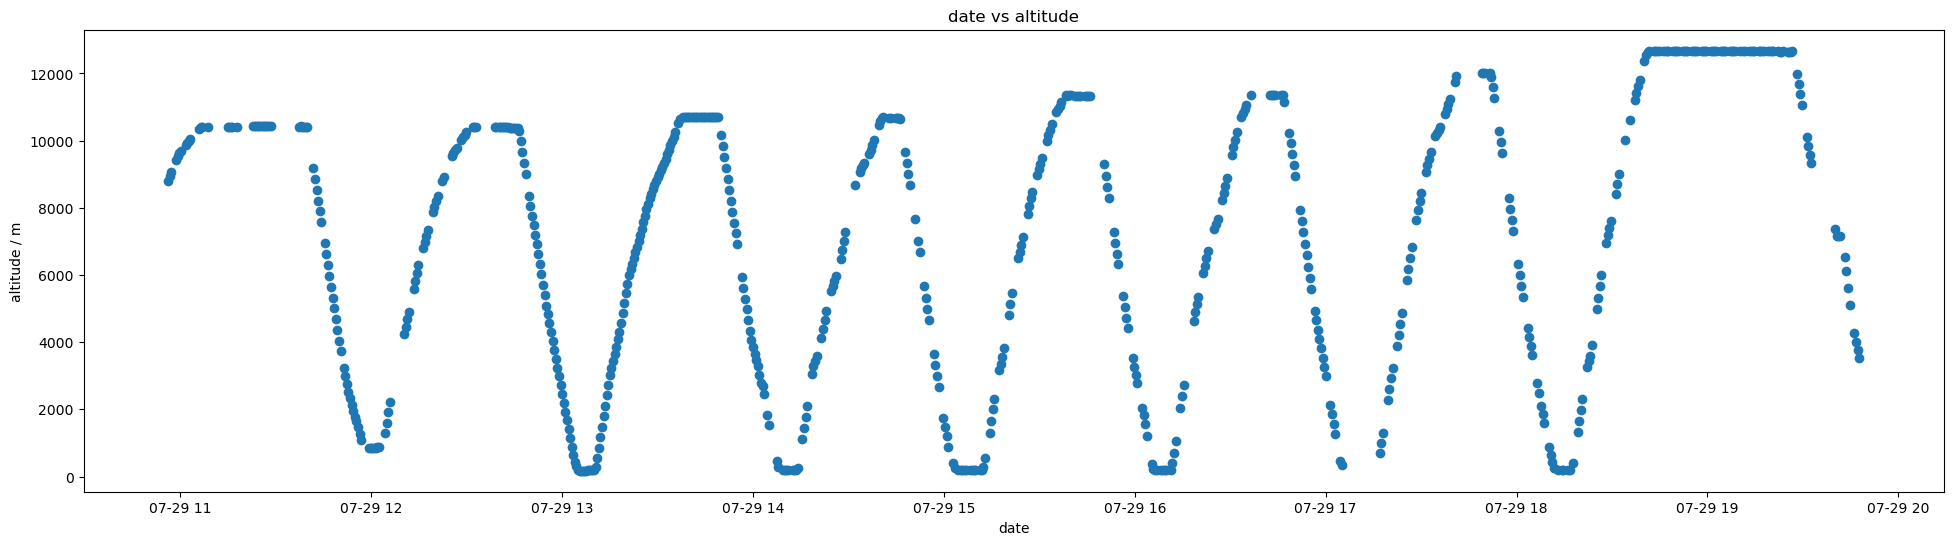

In [7]:
## Plot of altitude for one day
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][df["date"]< "2016-07-30"], y = df["Altitude"][df["date"]< "2016-07-30"])
plt.xlabel("date")
plt.ylabel("altitude / m")
plt.title("date vs altitude")
plt.show()

## Source rate

Source of $OH$:

$O(^1D) + H_2O → 2OH$

$O(^1D) + M → O^3P + M$

Data used based on $O(^1D) + N_2 → O(^3P) + N$

The rate equation for this is $2 \cdot k[O^1D][H_2O]$

Need to calculate $[O^1D]$ indirectly using data for $[O_3]$

Assumed to be in steady state - due to its short lifetime

So $\frac{d[O^1D]}{dt} = J[O_3] - k_1[O^1D][H_2O] - k_2[O^1D][M] = 0$

$[O^1D]_{SS} = \frac{J[O_3]}{k_1[H_2O] + k_2[M]}$

$(M = \frac{p}{kT})$

$k = Ae^{-\frac{E_a}{RT}}$ to calculate temperature dependent rate constants

## Calculations for source rate
For rate constants - temperature dependent so use Arrhenius equation: $k = Ae^{-\frac{E_a}{RT}}$

Convert units for species so that everything is in units of $molecules \: cm^{-3}$ and calculate $[M]$ using $[M] = \frac{p}{kT}$ ($p$ is pressure in $Pa$, $k$ is Boltzmann's constant in $J \: K^-1$ and $T$ is temperature in $K$

$1 J = 1 \: kg \: m^2 \: s^{-2}$

$1 \: Pa = 1 \: N m^{-2}$

Multiply value of $[M]$ by $1 \times 10^{-6}$, so from $molecules \: m^{-3}$ to $molecules \: cm^{-3}$

Then for each timestep (row):
1. Create new, empty columns in dataset to store results of calculations
2. 
3. Calculate the source rate using $2 \cdot k[O^1D][H_2O]$

In [8]:
## Unit conversions
from datetime import datetime, timezone
import numpy as np
from pytz import timezone

kb = 1.38e-23 # J K^−1 Boltzmann's constant

for i in range(len(df)):
    # Convert the dates to a timestamp value so that the difference between times can be calculated as an integer
    df.loc[i, "t"] = df["UTC_Start_dt"][i].replace().timestamp() - df["UTC_Start_dt"][0].replace().timestamp()
    df.loc[i, "M"] = ((df.loc[i, "Pres"] * 100) / (kb * df.loc[i, "Temp"])) * 1e-6 ## molecules cm^3 pressure was in hPa

df.head()


,Temp,Pres,UTC_Start_dt,lat,lon,Altitude,jO3_O2_O1D_CAFS,O3_M,H2O_M,OH_ATHOS,CO_M,CH4_M,PAN_M,date,t,M
0,249.265,343.334,2016-07-29 10:56:10-04:00,33.01171,241.10200,8804.58,0.000009,8.640570e-08,0.000447,0.300,7.233967e-08,0.000002,2.855530e-10,2016-07-29 10:56:10-04:00,0.0,9.981054e+18
1,248.771,337.478,2016-07-29 10:56:40-04:00,32.96985,241.04760,8931.10,0.000009,7.601130e-08,0.000332,0.300,6.900650e-08,0.000002,2.855530e-10,2016-07-29 10:56:40-04:00,30.0,9.830297e+18
2,248.851,331.741,2016-07-29 10:57:10-04:00,32.92798,240.99323,9057.14,0.000009,8.291030e-08,0.000158,0.300,7.108760e-08,0.000002,2.855530e-10,2016-07-29 10:57:10-04:00,60.0,9.660079e+18
3,246.160,315.391,2016-07-29 10:58:40-04:00,32.80281,240.83030,9425.14,0.000010,8.132570e-08,0.000169,0.276,6.804040e-08,0.000002,2.855530e-10,2016-07-29 10:58:40-04:00,150.0,9.284376e+18
4,245.201,309.998,2016-07-29 10:59:10-04:00,32.76114,240.77659,9550.39,0.000010,8.148520e-08,0.000207,0.276,6.748330e-08,0.000002,2.855530e-10,2016-07-29 10:59:10-04:00,180.0,9.161310e+18


Calculate $[O^1D]$ using $[O^1D]_{SS} = \frac{J[O_3]}{k_1[H_2O] + k_2}$

(NOT $k_2[M]$ as this cancels out after the conversion to $molecules \: cm^{-3}$ for the other concentrations

Need to calculate $[O^1D]$ indirectly using data for $[O_3]$

Production

$O_3 + hv → O_2 + O(^1D)$

Loss

$O(^1D) + M → O(^3P) + M$

$O(^1D) + H_2O → 2OH$

Assumed to be in steady state - due to its short lifetime

So $\frac{d[O^1D]}{dt} = J[O_3] - k_1[O^1D][H_2O] - k_2[O^1D] = 0$

$[O^1D]_{SS} = \frac{J[O_3]}{k_1[H_2O] + k_2}$

$(M = \frac{p}{kT})$

$k = Ae^{-\frac{E_a}{RT}}$ to calculate temperature dependent rate constants

In [9]:
df['kH2O'] = 1.63e-10 * np.exp(--60/df["Temp"]) ## page 21 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kM'] = 2.15e-11 * np.exp(--110/df["Temp"]) ## ## page 21 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf


df["O3"] = df["O3_M"] * df["M"]
df["H2O"] = df["H2O_M"] *  df["M"]
df["[OH]_measured"] = df["OH_ATHOS"] * 1e-12 * df["M"] # in ppt


In [10]:
for i in range(len(df)):
    # df.loc[i, "O1D"] = (df["jO3_O2_O1D_CAFS"][i] * df["O3"][i]) / ((kH2O[i] * df["H2O"][i]) + (kM[i] * df["M"][i]))
    df.loc[i, "O1D"] = (df["jO3_O2_O1D_CAFS"][i] * df["O3_M"][i]) / ((df['kH2O'][i] * df["H2O_M"][i]) + (df['kM'][i]))
    
    # Photoloysis frequency, concentration of water etc on top of fraction
    df.loc[i, "source"] = 2 * df['kH2O'][i] * df["O1D"][i] * df["H2O"][i]
print(df["O1D"].mean())
print(df["source"].mean())
df.head()

# source should be 10e5

0.05354202636146678
714621.1551027566


,Temp,Pres,UTC_Start_dt,lat,lon,Altitude,jO3_O2_O1D_CAFS,O3_M,H2O_M,OH_ATHOS,...,date,t,M,kH2O,kM,O3,H2O,[OH]_measured,O1D,source
0,249.265,343.334,2016-07-29 10:56:10-04:00,33.01171,241.10200,8804.58,0.000009,8.640570e-08,0.000447,0.300,...,2016-07-29 10:56:10-04:00,0.0,9.981054e+18,2.073603e-10,3.342655e-11,8.624200e+11,4.459096e+15,2.994316e+06,0.023588,43620.676829
1,248.771,337.478,2016-07-29 10:56:40-04:00,32.96985,241.04760,8931.10,0.000009,7.601130e-08,0.000332,0.300,...,2016-07-29 10:56:40-04:00,30.0,9.830297e+18,2.074594e-10,3.345585e-11,7.472136e+11,3.262902e+15,2.949089e+06,0.021093,28556.022150
2,248.851,331.741,2016-07-29 10:57:10-04:00,32.92798,240.99323,9057.14,0.000009,8.291030e-08,0.000158,0.300,...,2016-07-29 10:57:10-04:00,60.0,9.660079e+18,2.074434e-10,3.345109e-11,8.009200e+11,1.528340e+15,2.898024e+06,0.023270,14755.202410
3,246.160,315.391,2016-07-29 10:58:40-04:00,32.80281,240.83030,9425.14,0.000010,8.132570e-08,0.000169,0.276,...,2016-07-29 10:58:40-04:00,150.0,9.284376e+18,2.079909e-10,3.361313e-11,7.550584e+11,1.570434e+15,2.562488e+06,0.023840,15574.051246
4,245.201,309.998,2016-07-29 10:59:10-04:00,32.76114,240.77659,9550.39,0.000010,8.148520e-08,0.000207,0.276,...,2016-07-29 10:59:10-04:00,180.0,9.161310e+18,2.081892e-10,3.367193e-11,7.465112e+11,1.895878e+15,2.528521e+06,0.024238,19133.519265


## Plot date vs source rate and compare with altitude 

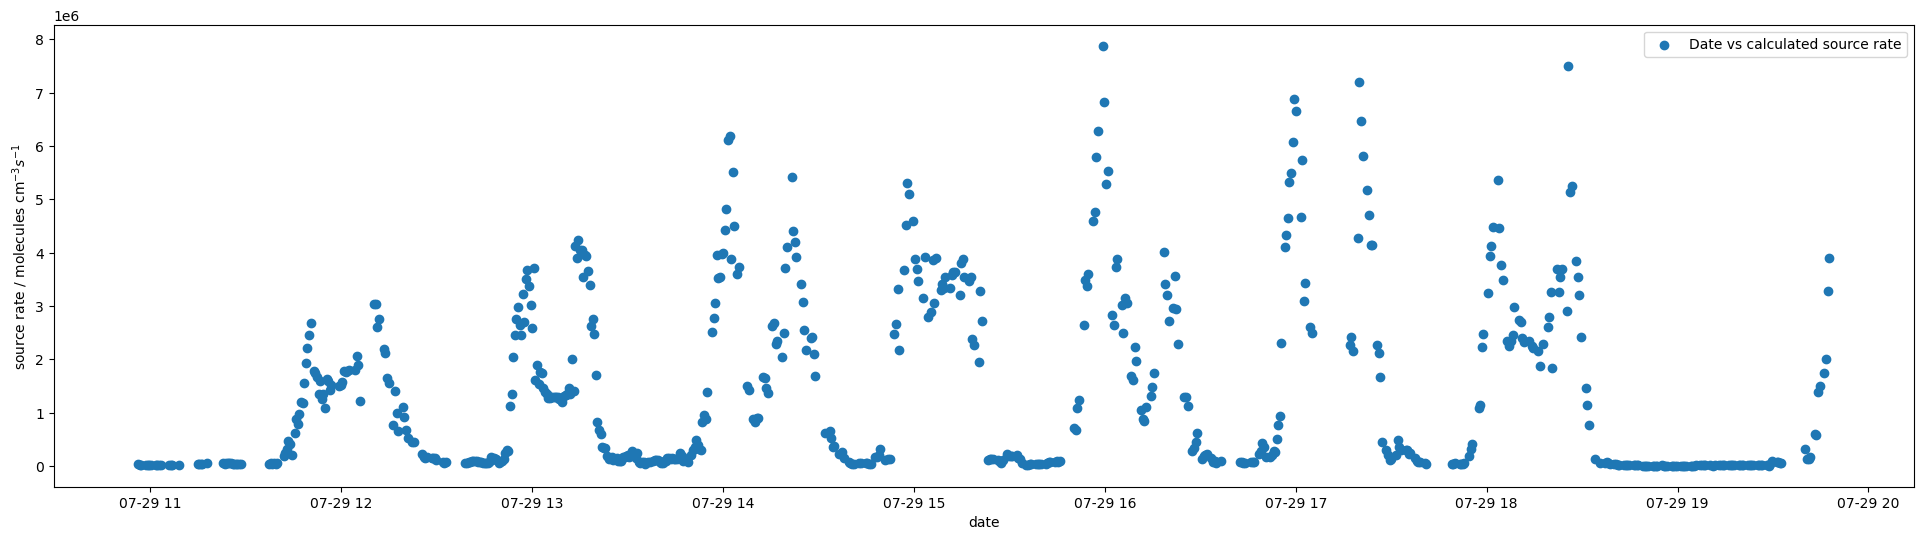

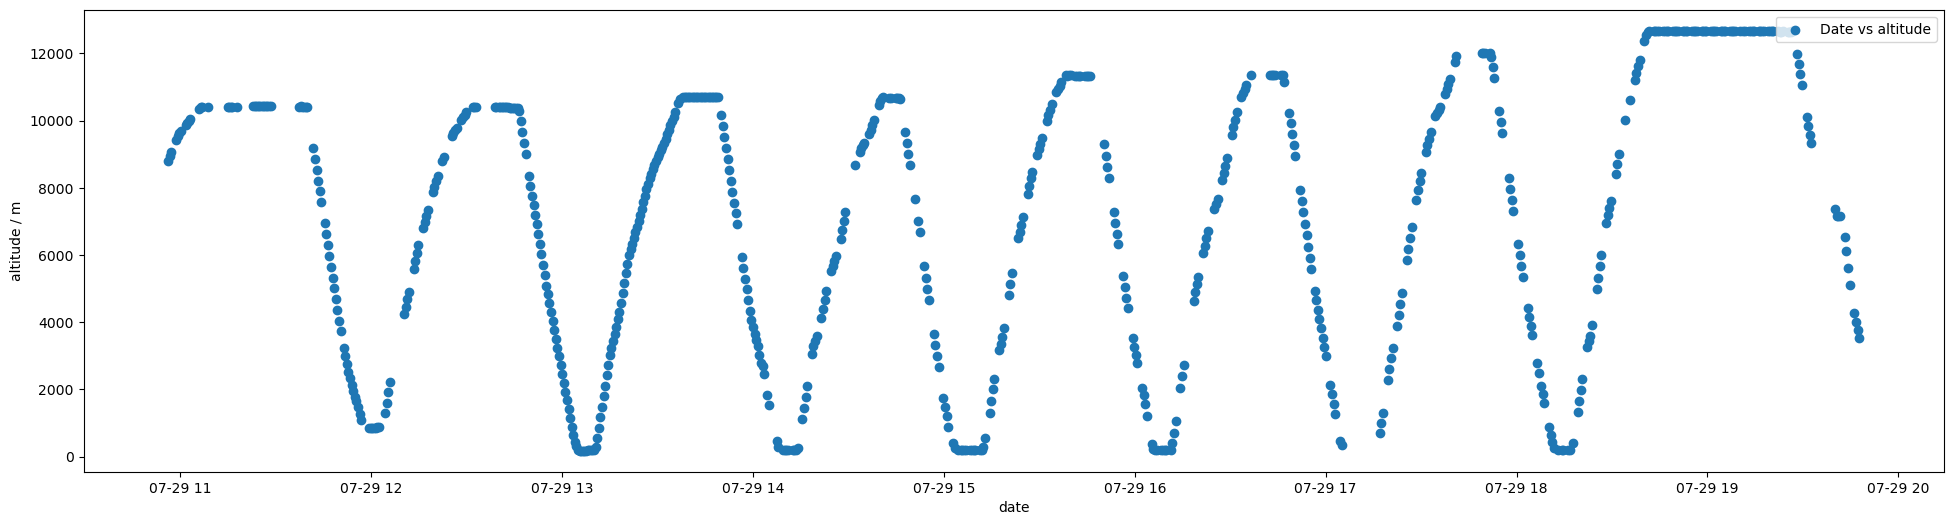

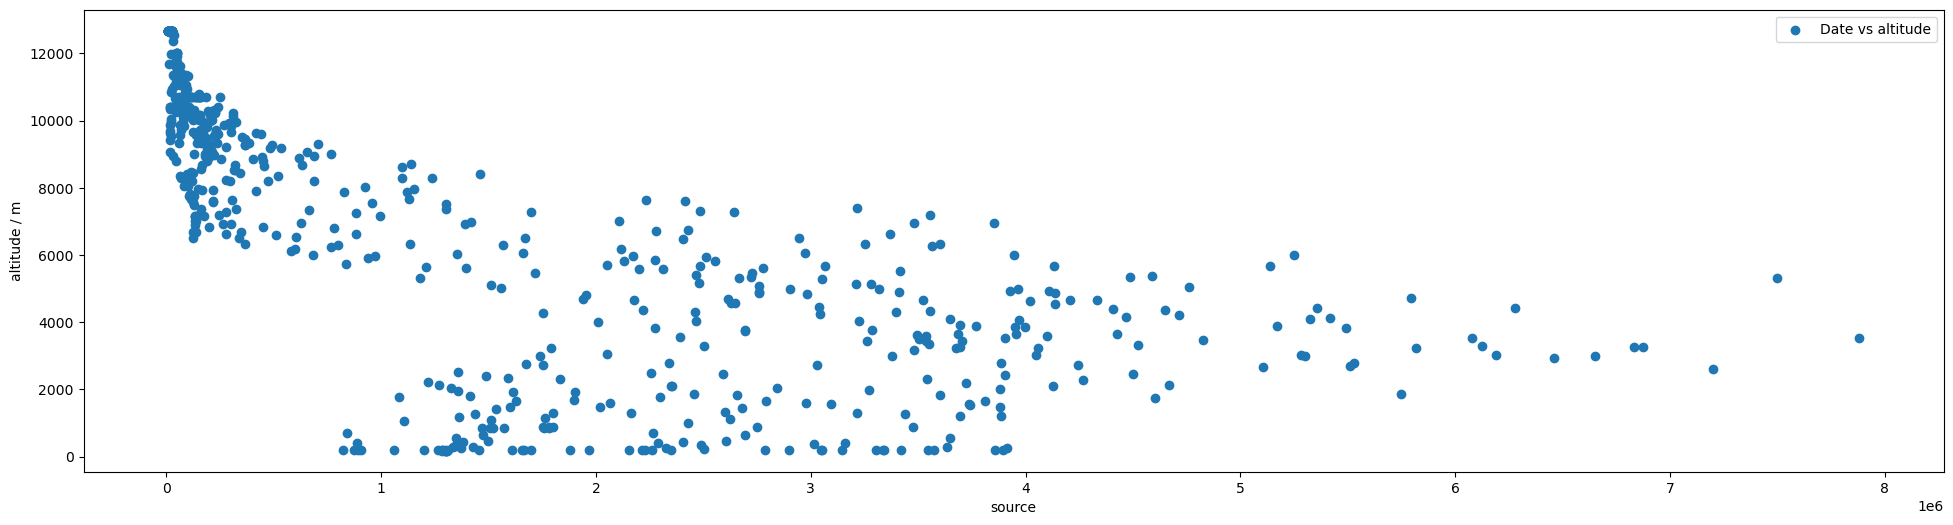

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][df["date"]< "2016-07-30"], y = df["source"][df["date"]< "2016-07-30"], label = "Date vs calculated source rate")
plt.xlabel("date")
plt.ylabel("source rate / molecules cm$^{-3} s^{-1}$")
plt.legend(loc='upper right')

fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][df["date"]< "2016-07-30"], y = df["Altitude"][df["date"]< "2016-07-30"], label = "Date vs altitude")
plt.xlabel("date")
plt.ylabel("altitude / m")
plt.legend(loc='upper right')

fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["source"][df["date"]< "2016-07-30"], y = df["Altitude"][df["date"]< "2016-07-30"], label = "Date vs altitude")
plt.xlabel("source")
plt.ylabel("altitude / m")
plt.legend(loc='upper right')

The graph shows that the source rate in OH is higher at low altitudes and lower at high altitudes - we can link this to the source of OH being the reaction between $O(^1D)$ and $H_2O$. Therefore this varying rate must be related to one (or both) of these species.

## Plot altitude dependence of $H_2O$ and $O(^1D)$

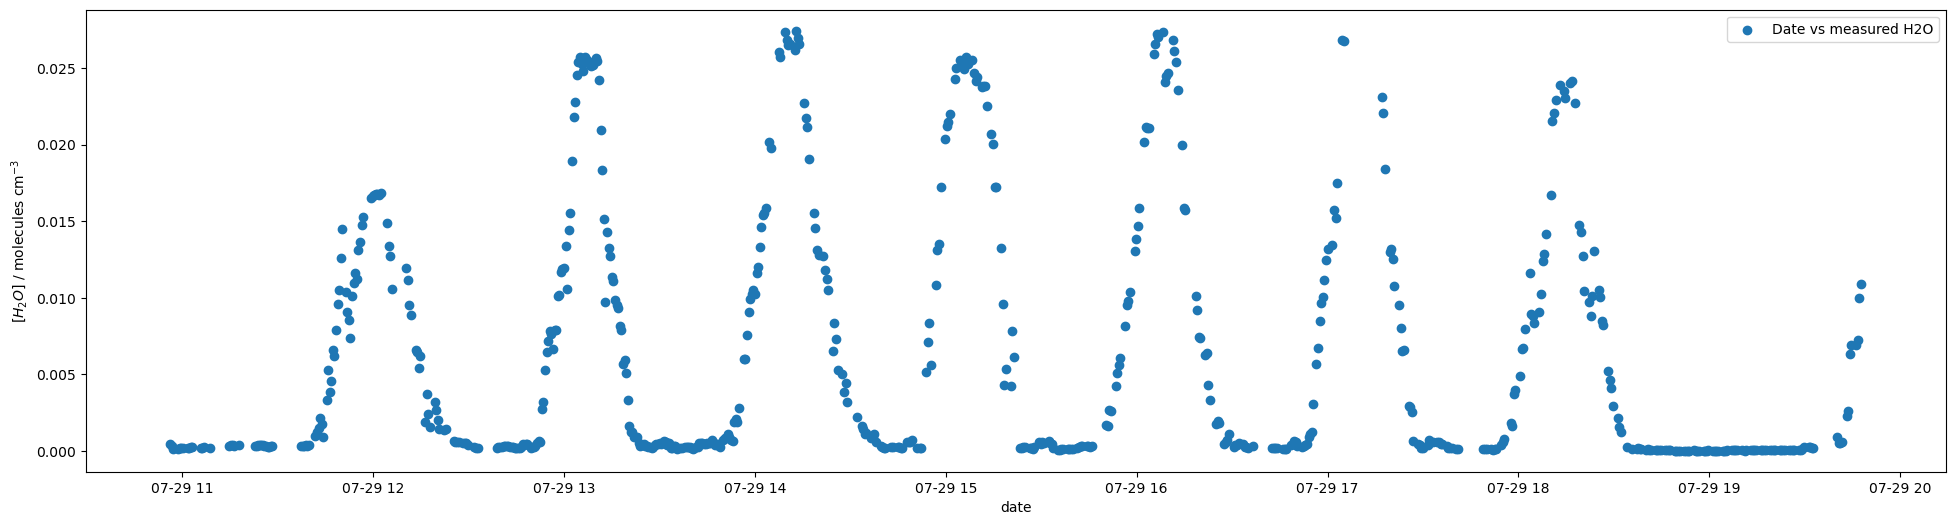

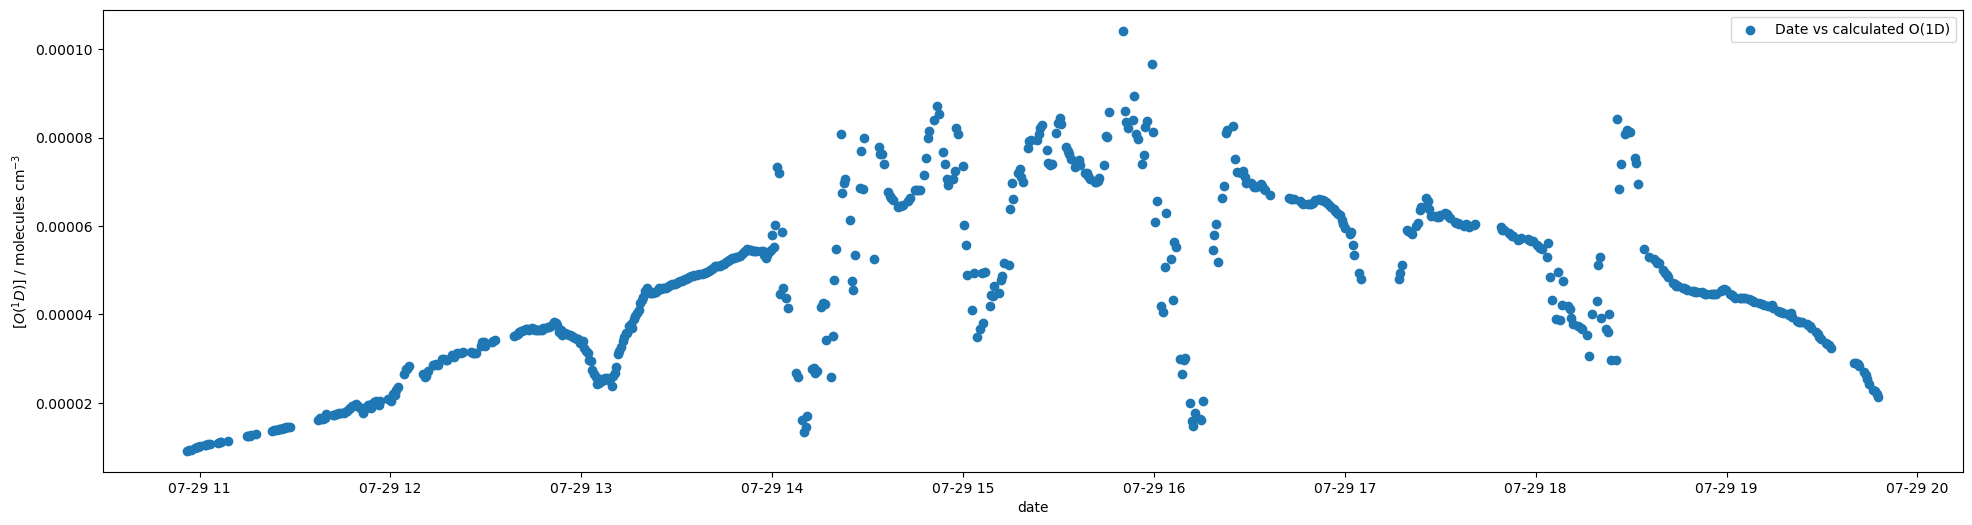

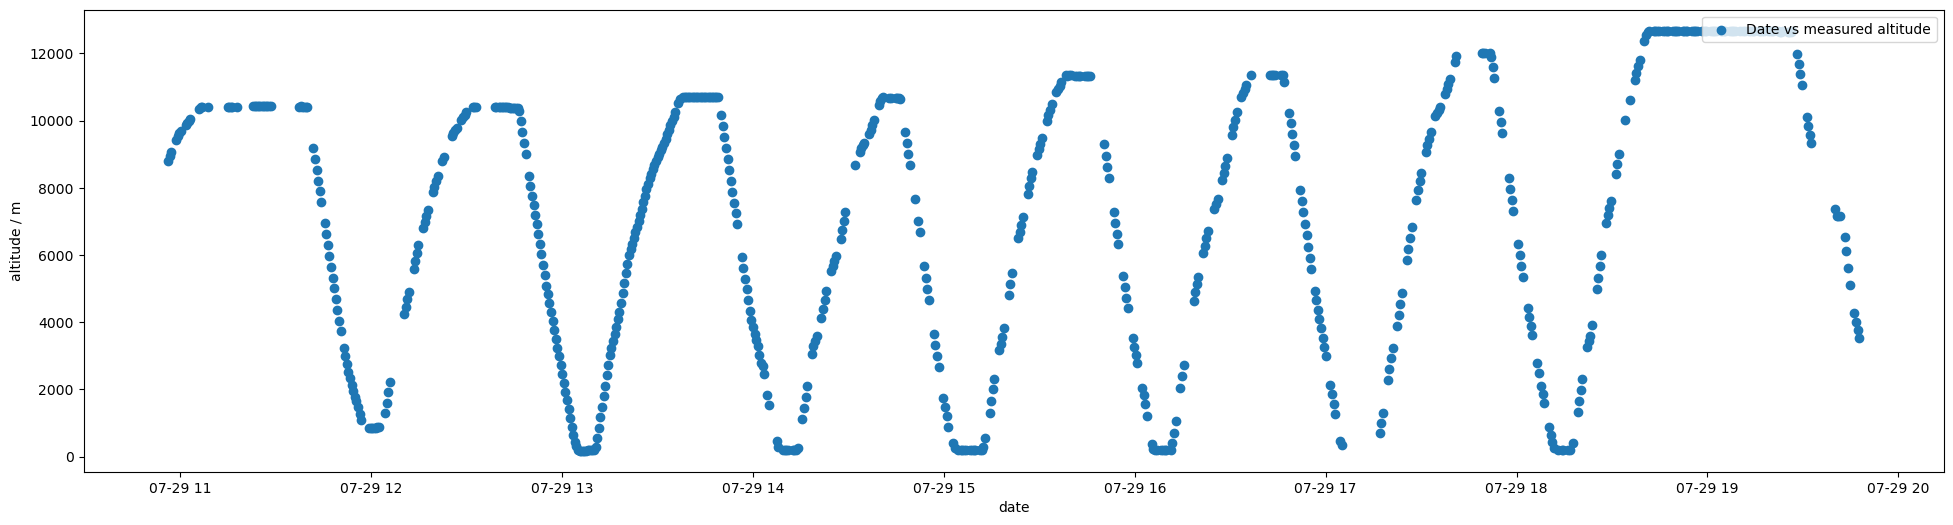

In [12]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][df["date"]< "2016-07-30"], y = df["H2O_M"][df["date"]< "2016-07-30"], label = "Date vs measured H2O")
plt.xlabel("date")
plt.ylabel("$[H_2O]$ / molecules cm$^{-3}$")
plt.legend(loc='upper right')

fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][df["date"]< "2016-07-30"], y = df["jO3_O2_O1D_CAFS"][df["date"]< "2016-07-30"], label = "Date vs calculated O(1D)")
plt.xlabel("date")
plt.ylabel("$[O(^1D)]$ / molecules cm$^{-3}$")
plt.legend(loc='upper right')

fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][df["date"]< "2016-07-30"], y = df["Altitude"][df["date"]< "2016-07-30"], label = "Date vs measured altitude")
plt.xlabel("date")
plt.ylabel("altitude / m")
plt.legend(loc='upper right')

## Local time
## Measured vs concentration - legend

From this graph it appears that there is a strong altitude dependence on concentrations of $H_2O$ in the atmosphere and the graph for $H_2O$ vs date is very similar to the graph for altitude vs date.

Seems that $H_2O$ has the bigger altitude dependence, whereas $O(^1D)$ seems to be affected more by the hour of day.

## Box model equation to find [OH]

## Steady state of OH

As $\frac{d[OH]}{dt} = Σsources - Σsinks$

$\frac{d[OH]}{dt} = P(OH) - k_1[OH][CO] - k_2[CH_4][OH]$

At steady state the sources and sinks balance:

$P(OH) - k_1[OH][CO] - k_2[CH_4][OH] = 0$

As we do not know [OH] (calculated) yet we cannot calculate the sink rate however we can use the steady state approximation to rearrange to find $[OH]$ from the other known values

$P(OH) = k_1[OH][CO] + k_2[CH_4][OH]$

$P(OH) = [OH](k_1[CO] + k_2[CH_4])$

$[OH] = \frac{p(OH)}{(k_1[CO] + k_2[CH4])}$

$[OH] = \frac{S}{(k_1[CO] + k_2[CH_4])}$

In [13]:
df["source"].mean()

np.float64(714621.1551027566)

In [14]:
df['kCO'] = 1.85e-13 * np.exp(--65/(df['Temp'])) ## page 484 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kCH4'] = 2.45e-12 * np.exp(-1775/df['Temp']) ## page 106 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df["CO"] = df['CO_M'] * df["M"]
df["CH4"] = df['CH4_M'] * df["M"]

for i in range(len(df)):
    df.loc[i, "[OH]_calc"] = (df.loc[i, "source"])/ ((df['kCO'][i] * df["CO"][i]) + (df['kCH4'][i] * df["CH4"][i]))
df["[OH]_calc"]

0       2.077319e+05
1       1.438663e+05
2       7.379482e+04
3       8.497041e+04
4       1.069334e+05
            ...     
6545    5.183911e+06
6546    5.348110e+06
6547    5.456484e+06
6548    5.348356e+06
6549    6.759650e+06
Name: [OH]_calc, Length: 6550, dtype: float64

## Calculations - sinks

Sink = $k_1[OH][CO] + k_2[CH_4][OH]$

Use the _calculated_ value of $[OH]$ for this

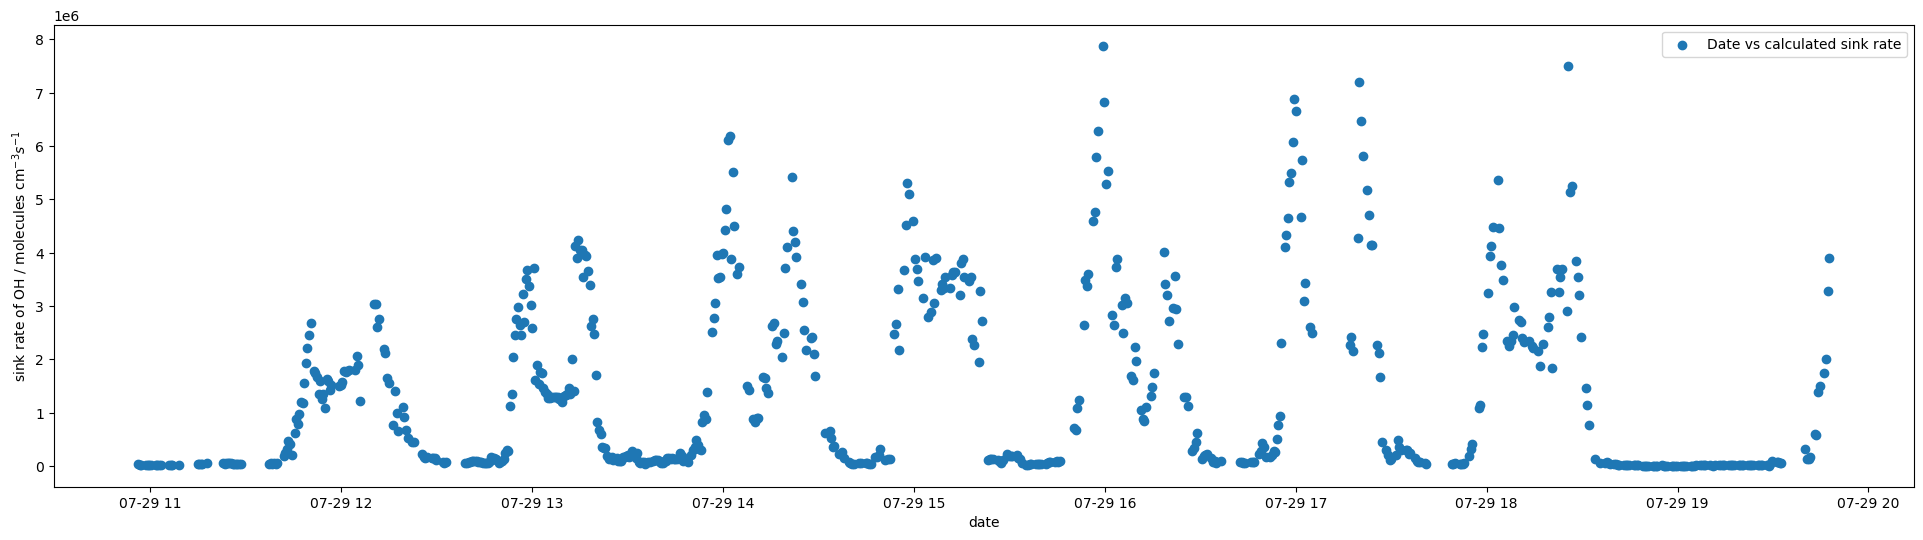

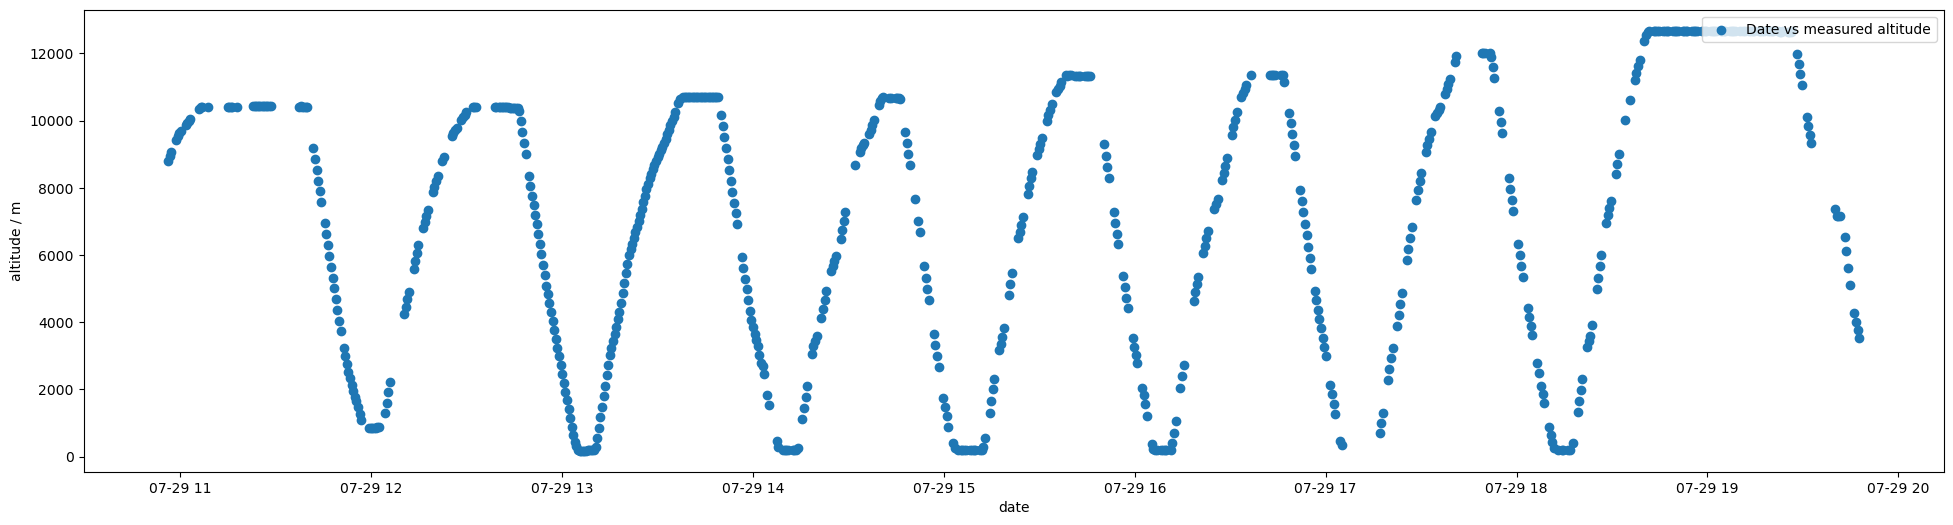

In [15]:
for i in range(len(df)):
    df.loc[i, "sink"] = (df['kCO'][i] * df["[OH]_calc"][i] * df['CO'][i]) + (df['kCH4'][i] * df["CH4"][i] * df["[OH]_calc"][i])

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][df["date"]< "2016-07-30"], y = df["sink"][df["date"]< "2016-07-30"], label = "Date vs calculated sink rate")
plt.xlabel("date")
plt.ylabel("sink rate of OH / molecules cm$^{-3} s^{-1}$")
plt.legend(loc='upper right')

fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][df["date"]< "2016-07-30"], y = df["Altitude"][df["date"]< "2016-07-30"], label = "Date vs measured altitude")
plt.xlabel("date")
plt.ylabel("altitude / m")
plt.legend(loc='upper right')

## $\frac{d[OH]}{dt} = P - L$ (production P is source rate, loss L is sink rate)

In [16]:
## Checking values for d[OH]/dt are 0 (or as close to 0 as can be represented by a computer)
for i in range(len(df)):
    df.loc[i, "dOH/dt"] = (df['source'][i] - df['sink'][i])
df['dOH/dt']

0       0.000000e+00
1      -3.637979e-12
2       0.000000e+00
3      -1.818989e-12
4       0.000000e+00
            ...     
6545    0.000000e+00
6546   -9.313226e-10
6547    0.000000e+00
6548   -9.313226e-10
6549    0.000000e+00
Name: dOH/dt, Length: 6550, dtype: float64

## Plotting calculated $[OH]_{SS}$ vs measured $[OH]$ from ATom data

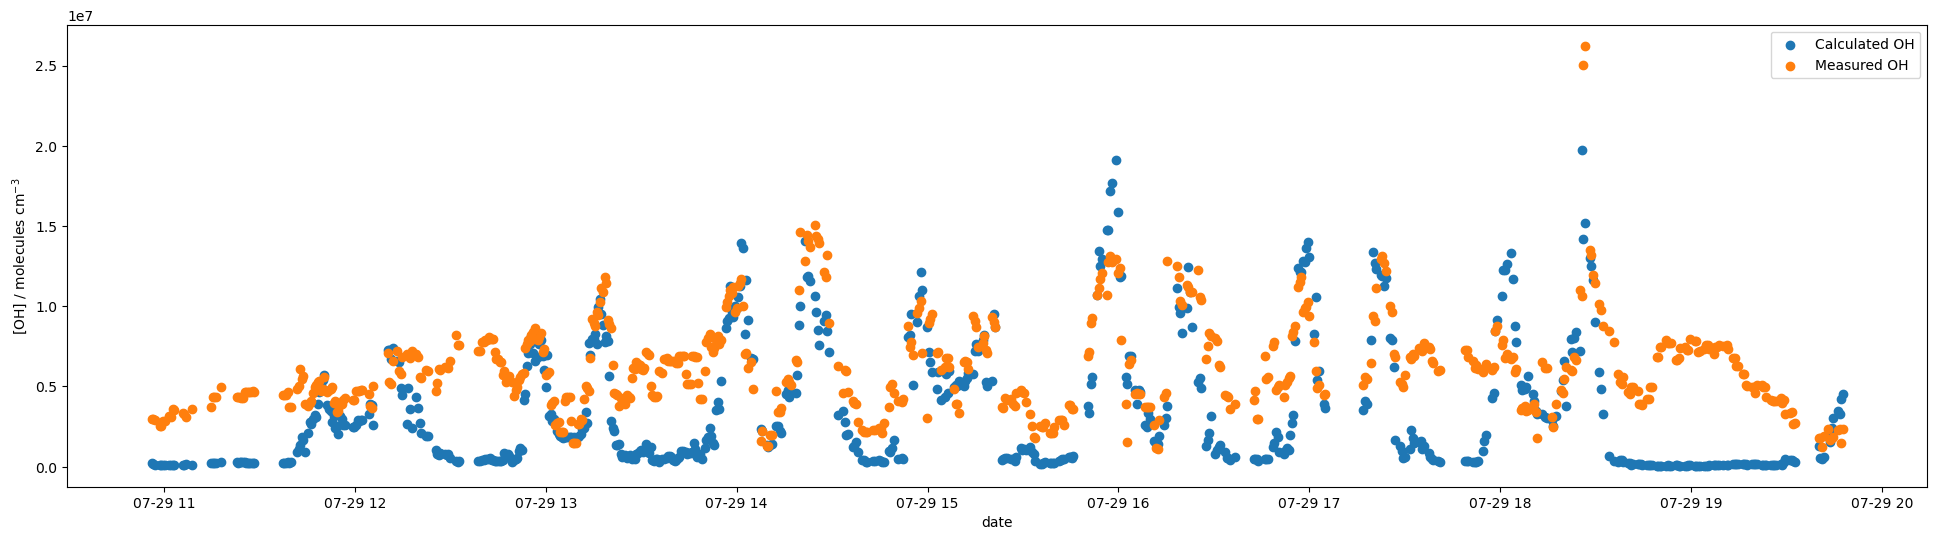

In [17]:
fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][df["date"] < "2016-07-30"], y = df["[OH]_calc"][df["date"] < "2016-07-30"], label = "Calculated OH")
plt.xlabel("date")
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.legend()
# fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][df["date"] < "2016-07-30"], y = df["[OH]_measured"][df["date"] < "2016-07-30"], label = "Measured OH")
plt.xlabel("date")
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.legend()

import pickle
with open("comparison.pkl", "wb") as f:
    pickle.dump(fig, f)

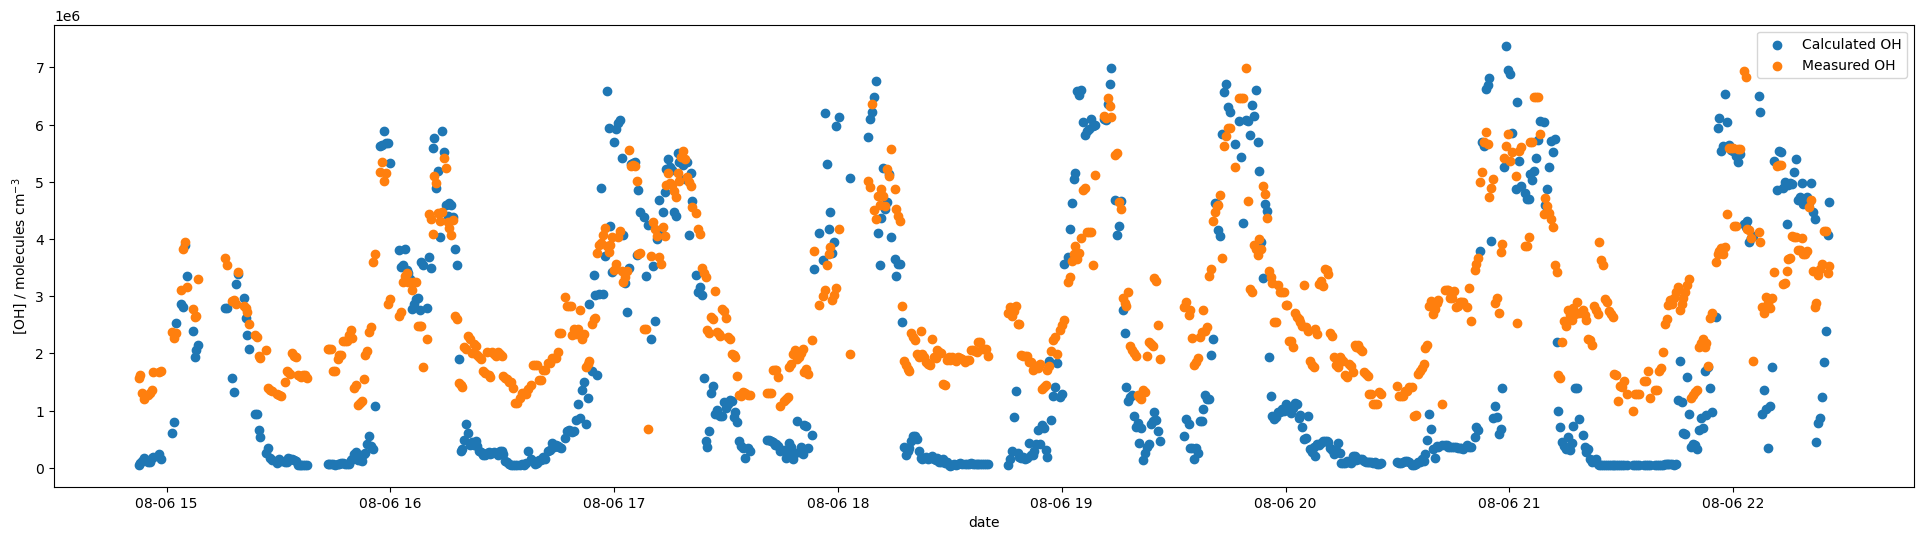

In [18]:
fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], y = df["[OH]_calc"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], label = "Calculated OH")
plt.xlabel("date")
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.legend()
# fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], y = df["[OH]_measured"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], label = "Measured OH")
plt.xlabel("date")
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.legend()


Comparison plots for 4 days

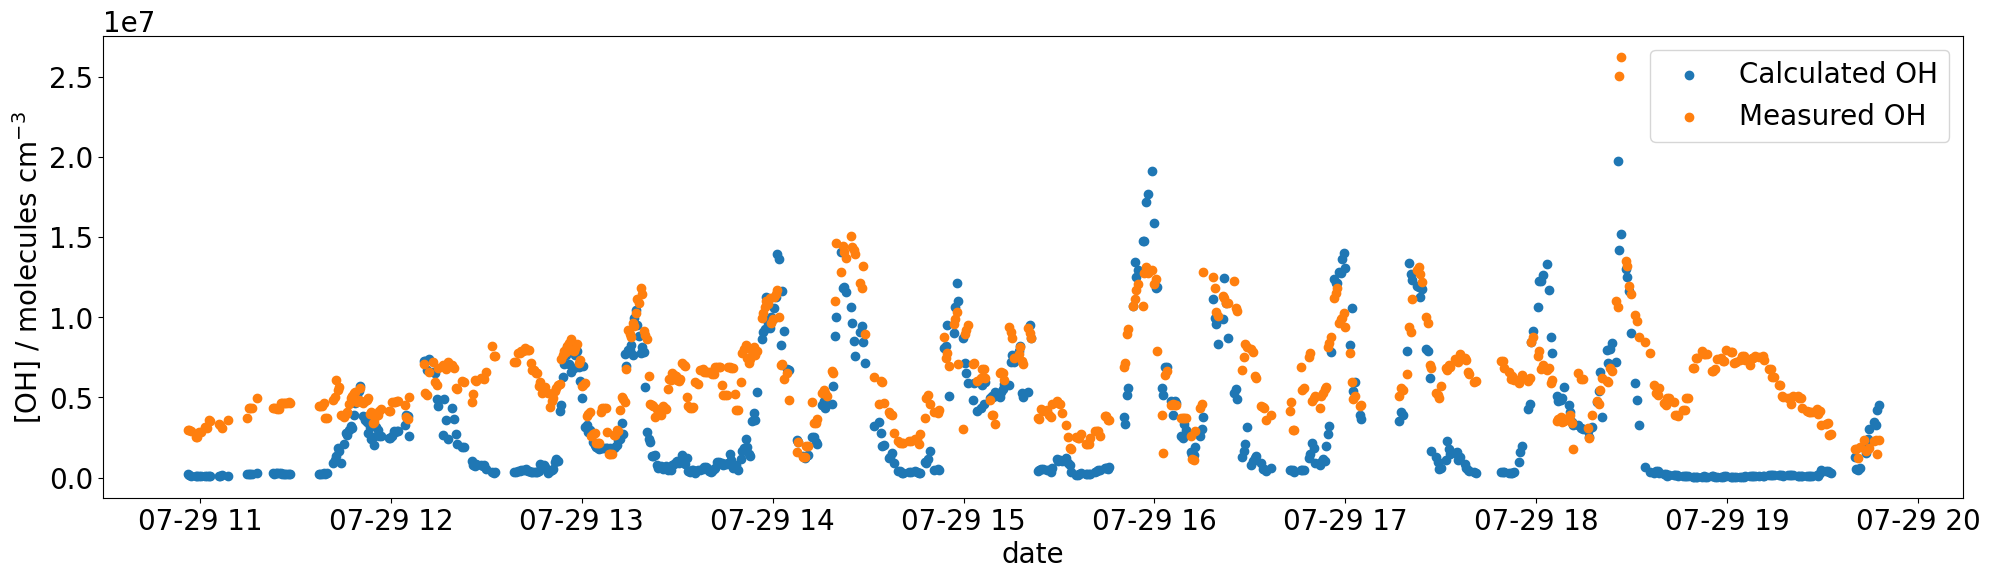

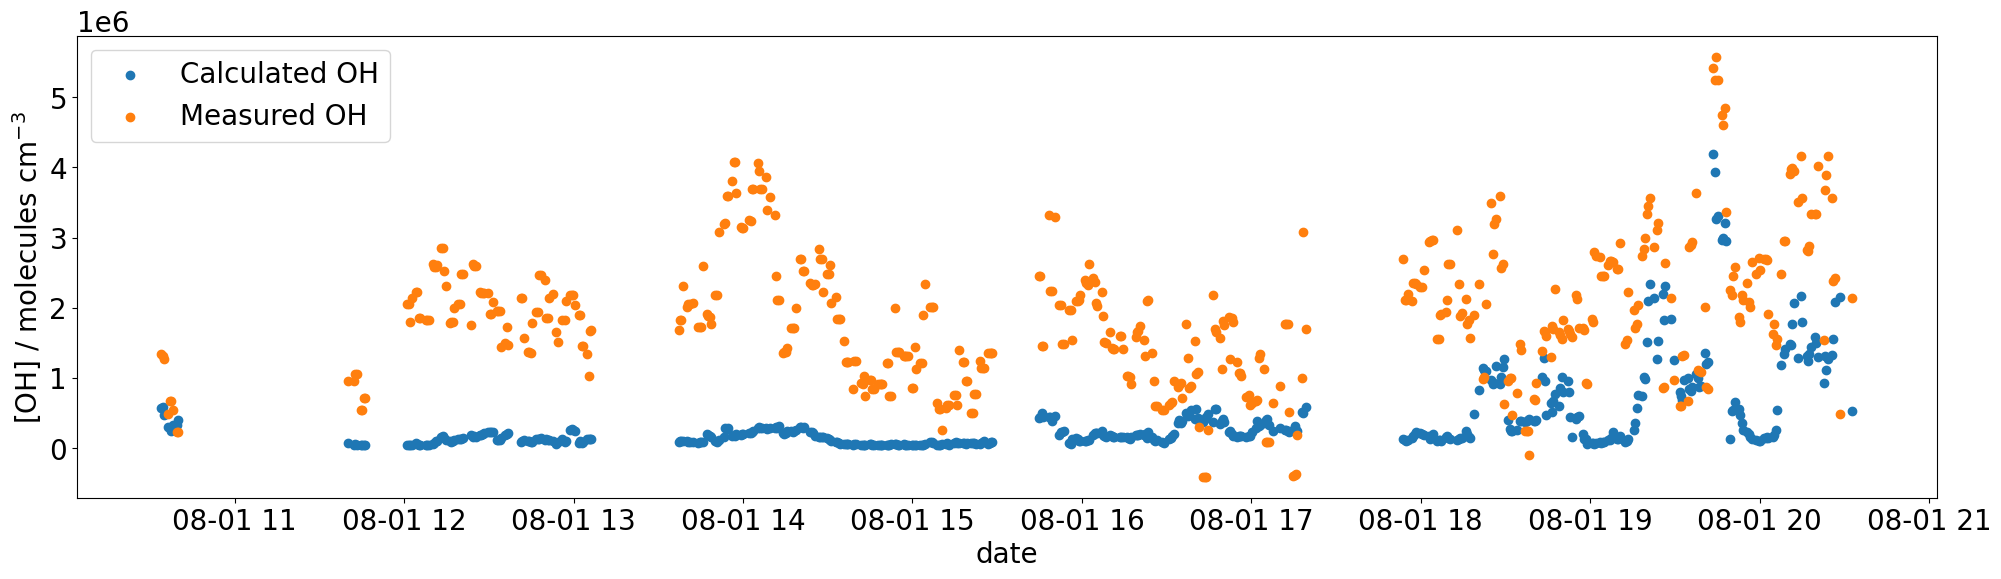

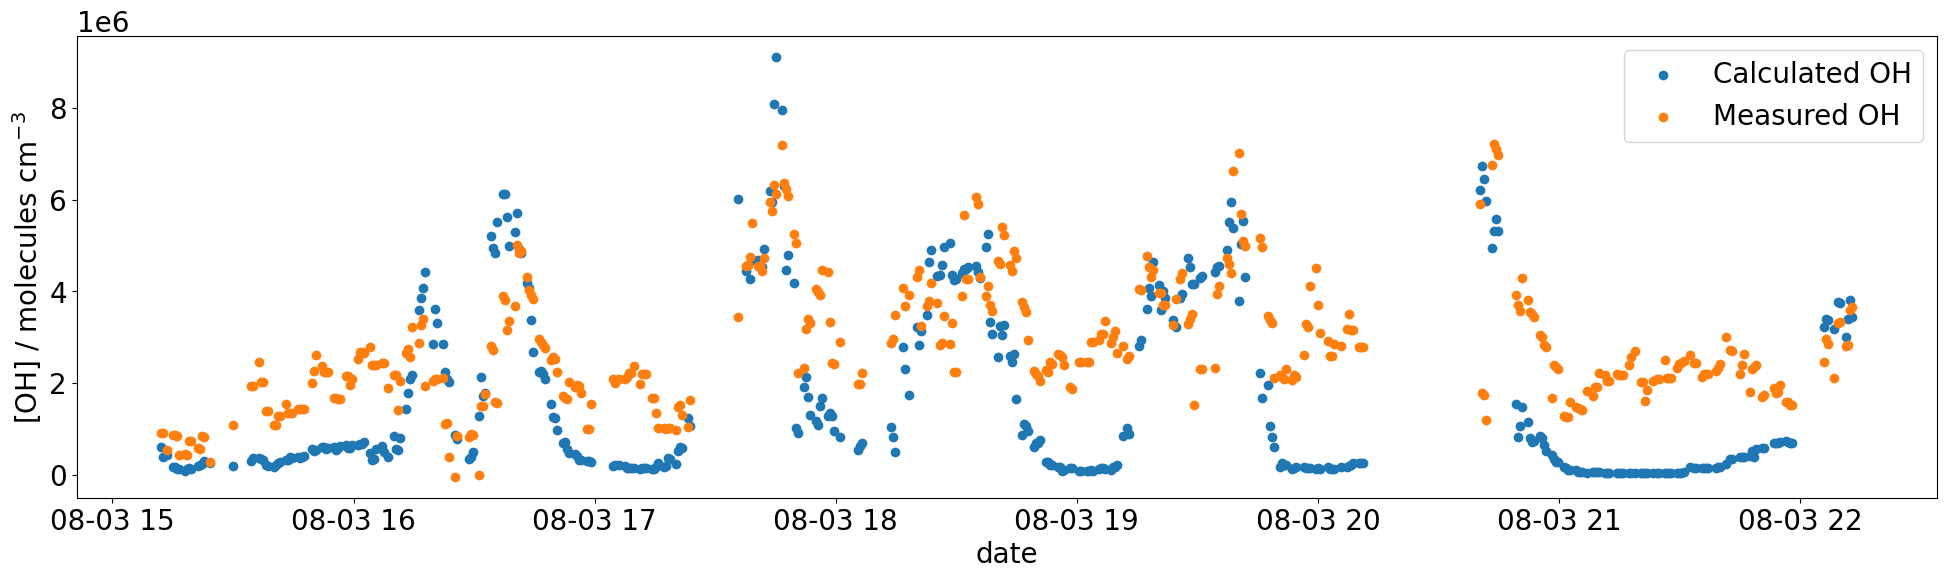

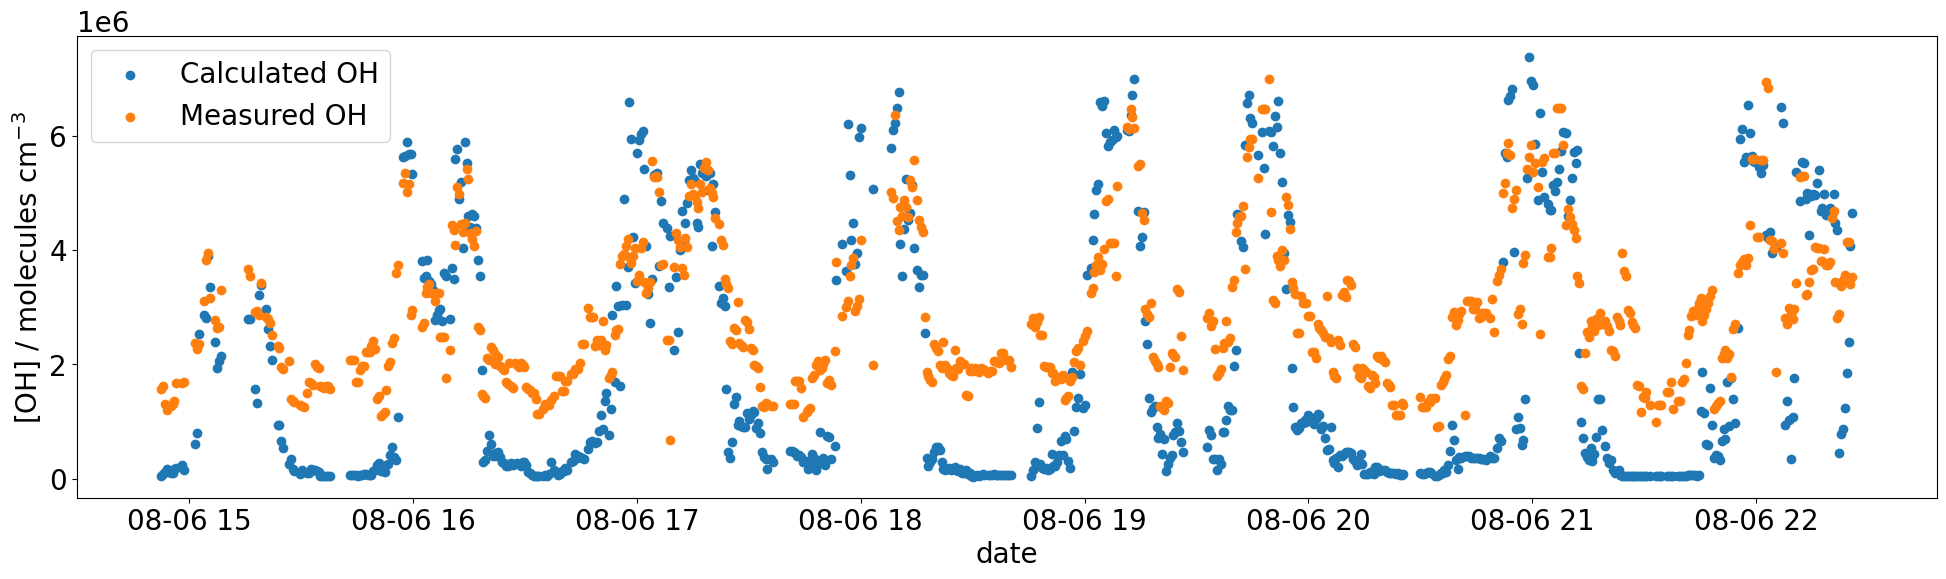

In [19]:
plt.rcParams.update({'font.size':20})

fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], y = df["[OH]_calc"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], label = "Calculated OH")
plt.scatter(x = df["date"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], y = df["[OH]_measured"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], label = "Measured OH")
plt.xlabel("date")
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.legend(prop={'size':20})

fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][(df["date"] > "2016-07-30") & (df["date"] < "2016-08-02")], y = df["[OH]_calc"][(df["date"] > "2016-07-30") & (df["date"] < "2016-08-02")], label = "Calculated OH")
plt.scatter(x = df["date"][(df["date"] > "2016-07-30") & (df["date"] < "2016-08-02")], y = df["[OH]_measured"][(df["date"] > "2016-07-30") & (df["date"] < "2016-08-02")], label = "Measured OH")
plt.xlabel("date")
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.legend(prop={'size':20})

fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][(df["date"] > "2016-08-02") & (df["date"] < "2016-08-04")], y = df["[OH]_calc"][(df["date"] > "2016-08-02") & (df["date"] < "2016-08-04")], label = "Calculated OH")
plt.scatter(x = df["date"][(df["date"] > "2016-08-02") & (df["date"] < "2016-08-04")], y = df["[OH]_measured"][(df["date"] > "2016-08-02") & (df["date"] < "2016-08-04")], label = "Measured OH")
plt.xlabel("date")
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.legend(prop={'size':20})

fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(x = df["date"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], y = df["[OH]_calc"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], label = "Calculated OH")
plt.scatter(x = df["date"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], y = df["[OH]_measured"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")], label = "Measured OH")
plt.xlabel("date")
plt.ylabel("[OH] / molecules cm$^{-3}$")
plt.legend(prop={'size':20})

$r^2$ scores for 4 days

In [20]:
from sklearn.linear_model import LinearRegression
import sklearn
X = df[["[OH]_measured"]][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")]
y = df["[OH]_calc"][(df["date"] > "2016-07-28") & (df["date"] < "2016-08-01")]
print(sklearn.metrics.r2_score(X, y))

X = df[["[OH]_measured"]][(df["date"] > "2016-07-30") & (df["date"] < "2016-08-02")]
y = df["[OH]_calc"][(df["date"] > "2016-07-30") & (df["date"] < "2016-08-02")]
print(sklearn.metrics.r2_score(X, y))

X = df[["[OH]_measured"]][(df["date"] > "2016-08-02") & (df["date"] < "2016-08-04")]
y = df["[OH]_calc"][(df["date"] > "2016-08-02") & (df["date"] < "2016-08-04")]
print(sklearn.metrics.r2_score(X, y))

X = df[["[OH]_measured"]][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")]
y = df["[OH]_calc"][(df["date"] > "2016-08-05") & (df["date"] < "2016-08-07")]
print(sklearn.metrics.r2_score(X, y))

X = df[["[OH]_measured"]]
y = df["[OH]_calc"]
print(sklearn.metrics.r2_score(X, y))

-0.8510102763844323
-2.2020781021351863
-0.8404214954201956
-0.5187424420837601
0.0500446321955883


## Some exploratory comparison plots

### Ratio of modelled to measured

Text(0, 0.5, 'ratio of modelled [OH] / observed [OH]')

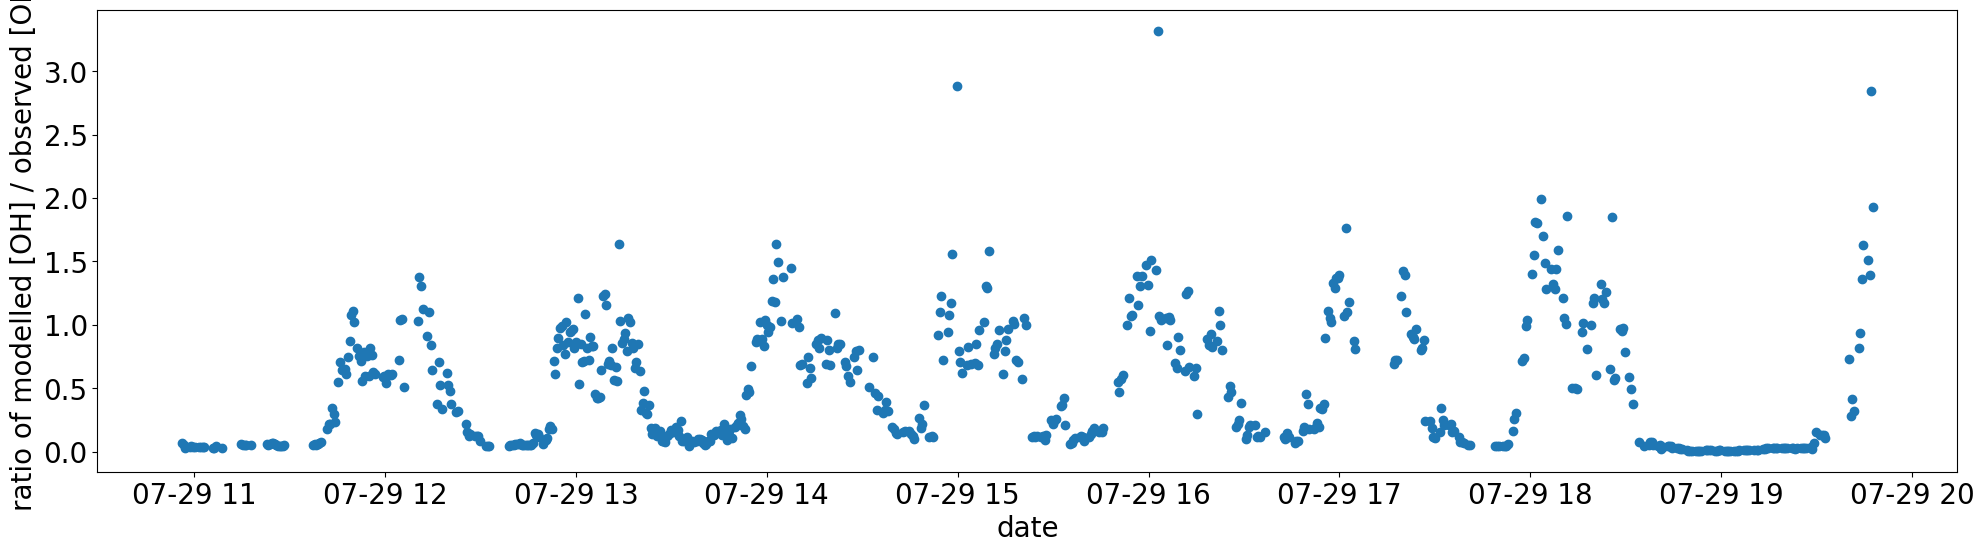

In [21]:
fig, ax = plt.subplots(figsize = (24, 6))
ratio = df["[OH]_calc"]/df["[OH]_measured"]
plt.scatter(x = df["date"][df["date"] < "2016-07-30"], y = ratio[df["date"] < "2016-07-30"])
plt.xlabel("date")
plt.ylabel("ratio of modelled [OH] / observed [OH]")

Fluctuation in modelled values is reflected here.

### Percentage difference

Using $PD = 100 \times \frac{(observation - model)}{(observation + model) / 2}$

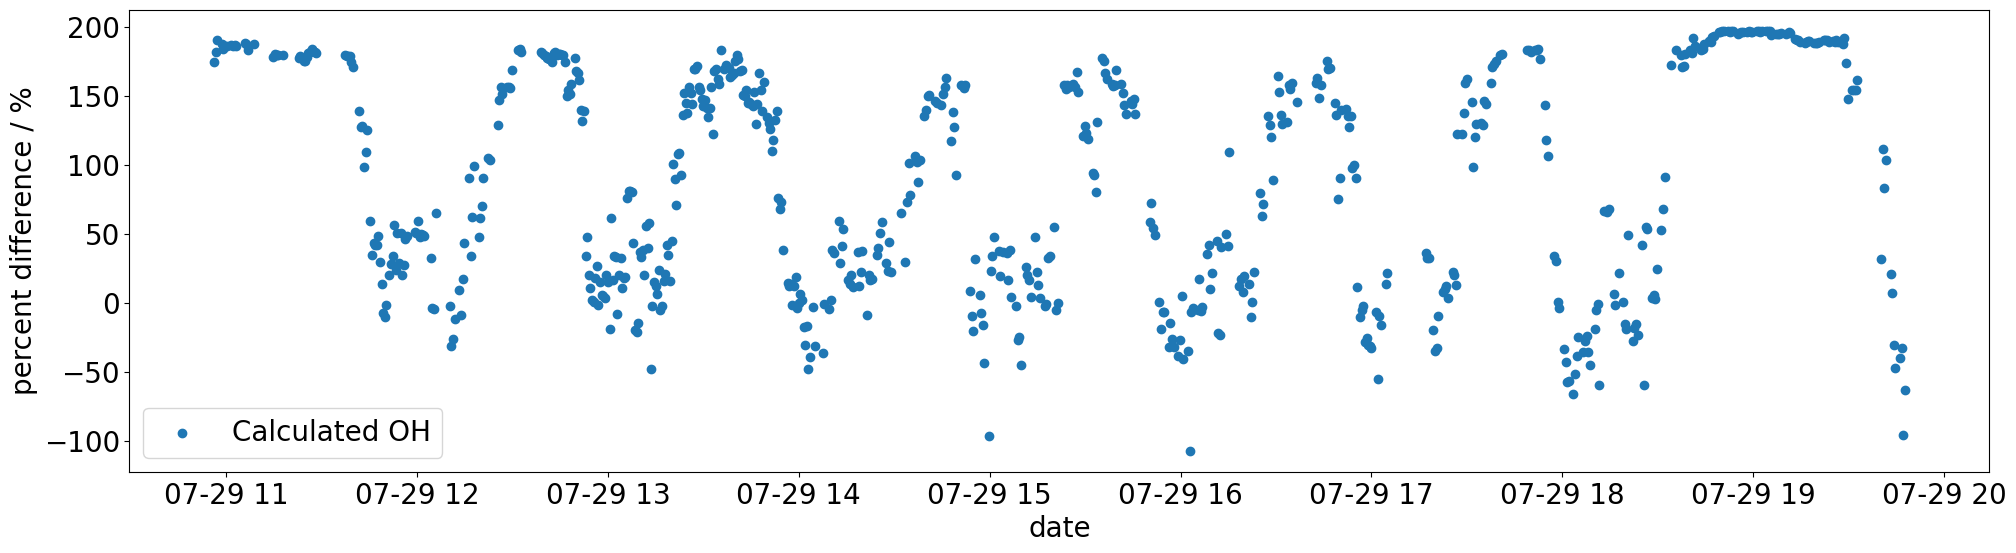

In [22]:
fig, ax = plt.subplots(figsize = (24, 6))
pd = 100 * ((df["[OH]_measured"] - df["[OH]_calc"]) / ((df["[OH]_measured"] + df["[OH]_calc"]) / 2))
plt.scatter(x = df["date"][df["date"] < "2016-07-30"], y = pd[df["date"] < "2016-07-30"], label = "Calculated OH")
plt.xlabel("date")
plt.ylabel("percent difference / %")
plt.legend()

Again, the fluctuation causes quite a big percentage difference at both ends of the y axis

### Scatterplot of modelled vs measured

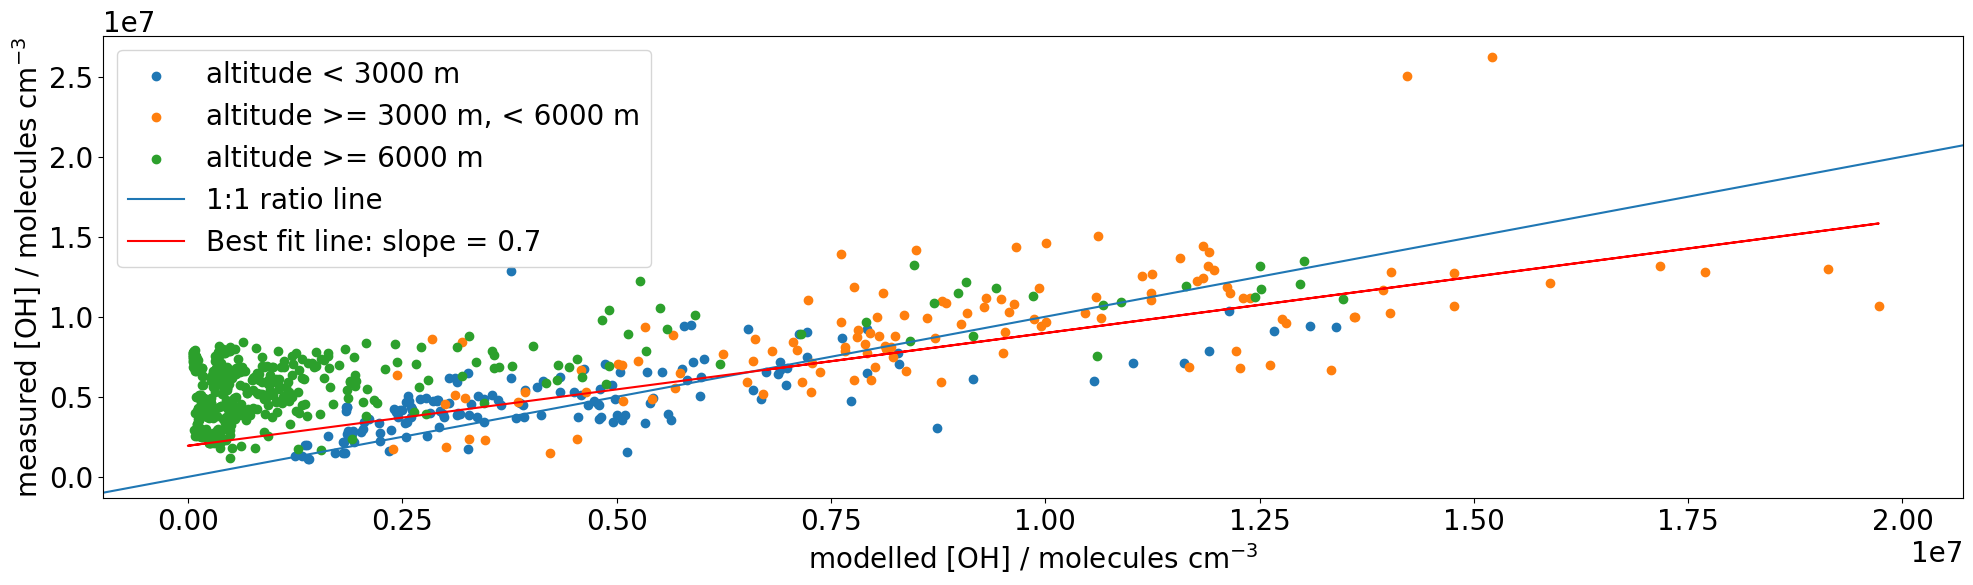

In [23]:
fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(df["[OH]_calc"][(df["date"] < "2016-07-30") & (df["Altitude"] < 3000)], y = df["[OH]_measured"][(df["date"] < "2016-07-30") & (df["Altitude"] < 3000)], label = "altitude < 3000 m")
# fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(df["[OH]_calc"][(df["date"] < "2016-07-30") & (df["Altitude"] >= 3000) & (df["Altitude"] < 6000)], y = df["[OH]_measured"][(df["date"] < "2016-07-30") & (df["Altitude"] >= 3000) & (df["Altitude"] < 6000)], label = "altitude >= 3000 m, < 6000 m")
# fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(df["[OH]_calc"][(df["date"] < "2016-07-30") & (df["Altitude"] >= 6000)], y = df["[OH]_measured"][(df["date"] < "2016-07-30") & (df["Altitude"] >= 6000)], label = "altitude >= 6000 m")
plt.xlabel("modelled [OH] / molecules cm$^{-3}$")
plt.ylabel("measured [OH] / molecules cm$^{-3}$")
ax.axline([0,0], [100,100], label = "1:1 ratio line")

slope, intercept = np.polyfit(df["[OH]_calc"], df["[OH]_measured"], 1)
x = df["[OH]_calc"]
y = df["[OH]_measured"]
plt.plot(x, slope * x + intercept, color='red', label=f'Best fit line: slope = {round(slope, 2)}')
plt.legend()
plt.show()

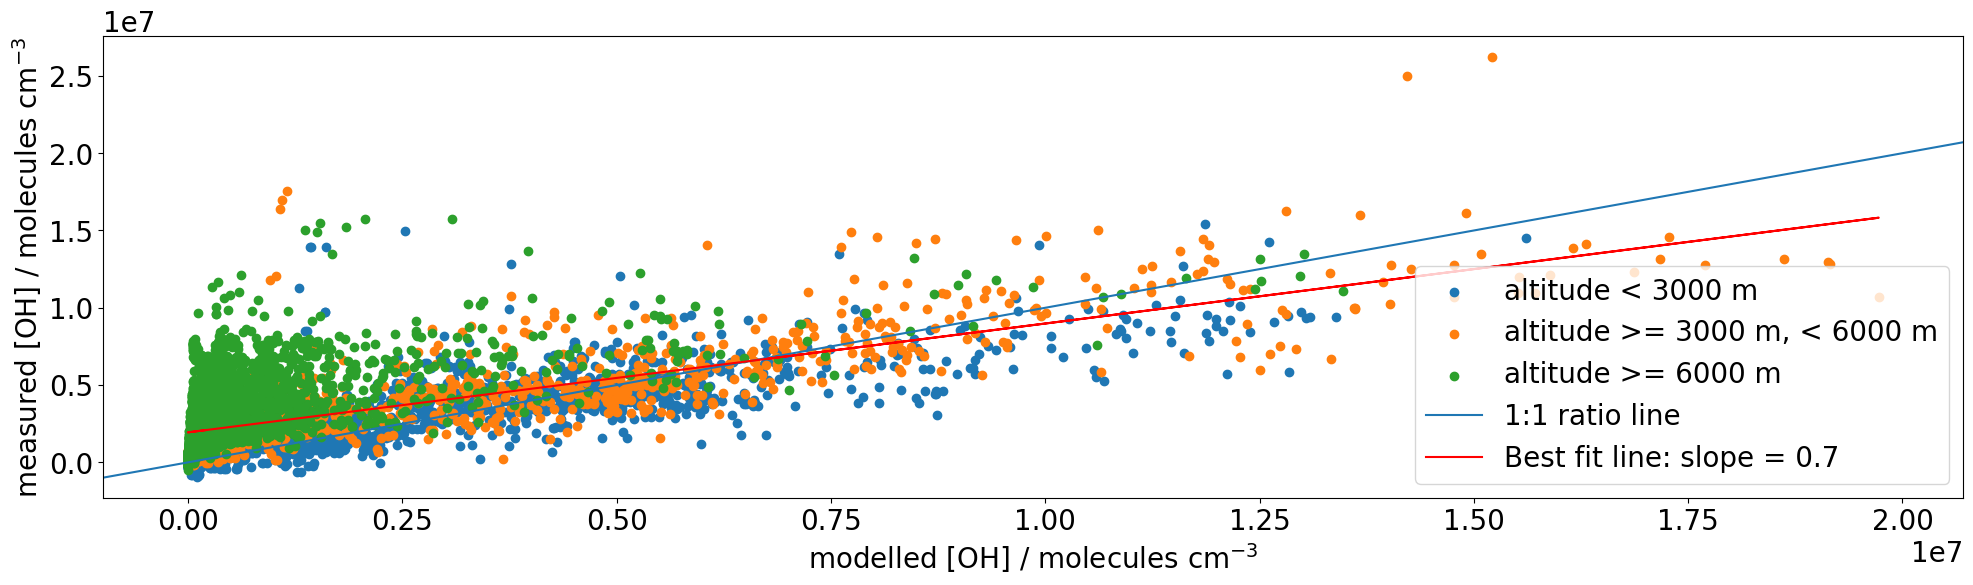

In [24]:
fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(df["[OH]_calc"][ (df["Altitude"] < 3000)], y = df["[OH]_measured"][(df["Altitude"] < 3000)], label = "altitude < 3000 m")
# fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(df["[OH]_calc"][(df["Altitude"] >= 3000) & (df["Altitude"] < 6000)], y = df["[OH]_measured"][(df["Altitude"] >= 3000) & (df["Altitude"] < 6000)], label = "altitude >= 3000 m, < 6000 m")
# fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(df["[OH]_calc"][(df["Altitude"] >= 6000)], y = df["[OH]_measured"][(df["Altitude"] >= 6000)], label = "altitude >= 6000 m")
plt.xlabel("modelled [OH] / molecules cm$^{-3}$")
plt.ylabel("measured [OH] / molecules cm$^{-3}$")
ax.axline([0,0], [100,100], label = "1:1 ratio line")

slope, intercept = np.polyfit(df["[OH]_calc"], df["[OH]_measured"], 1)
x = df["[OH]_calc"]
y = df["[OH]_measured"]
plt.plot(x, slope * x + intercept, color='red', label=f'Best fit line: slope = {round(slope, 2)}')
plt.legend()
plt.show()

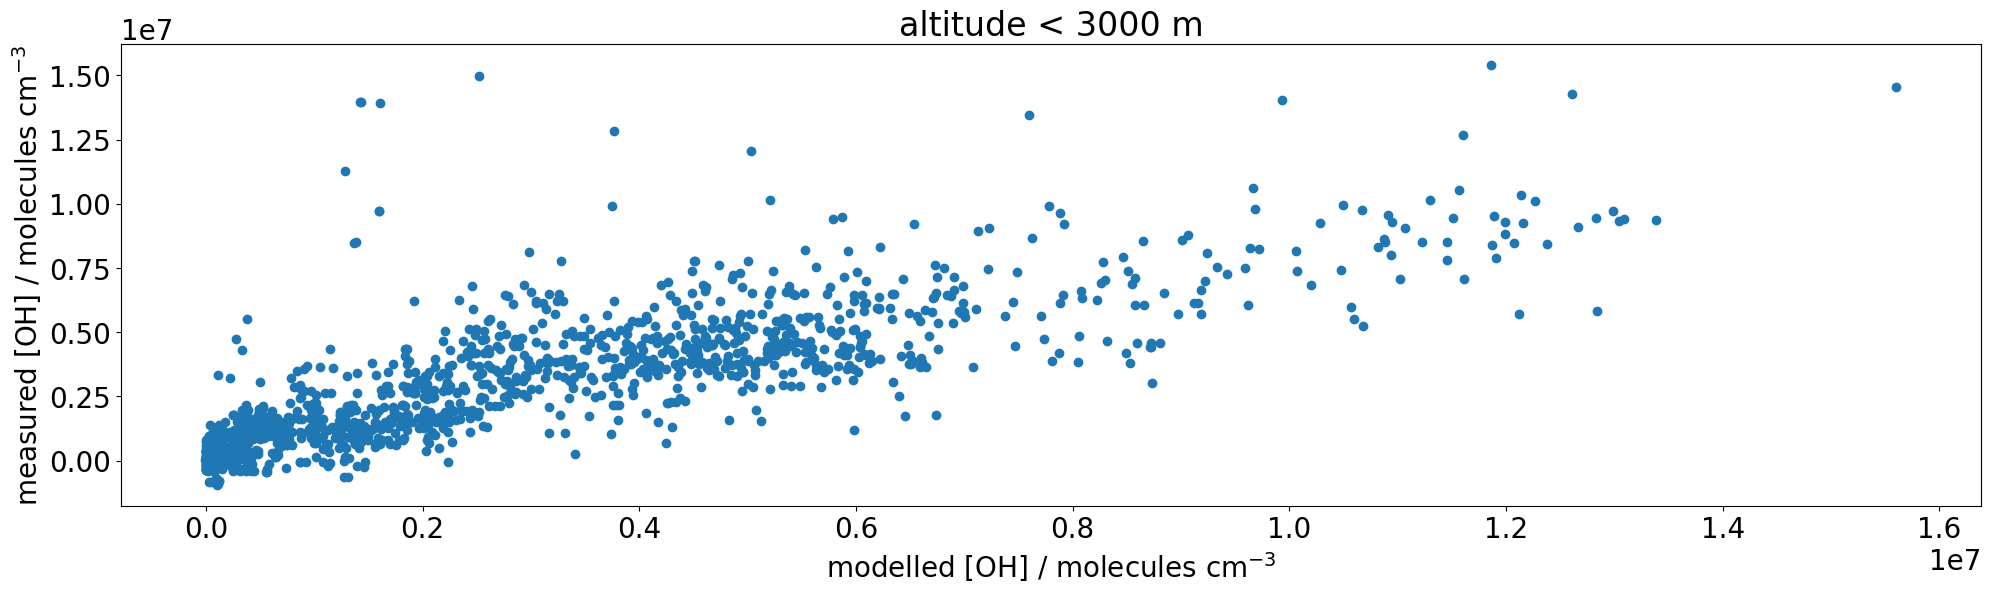

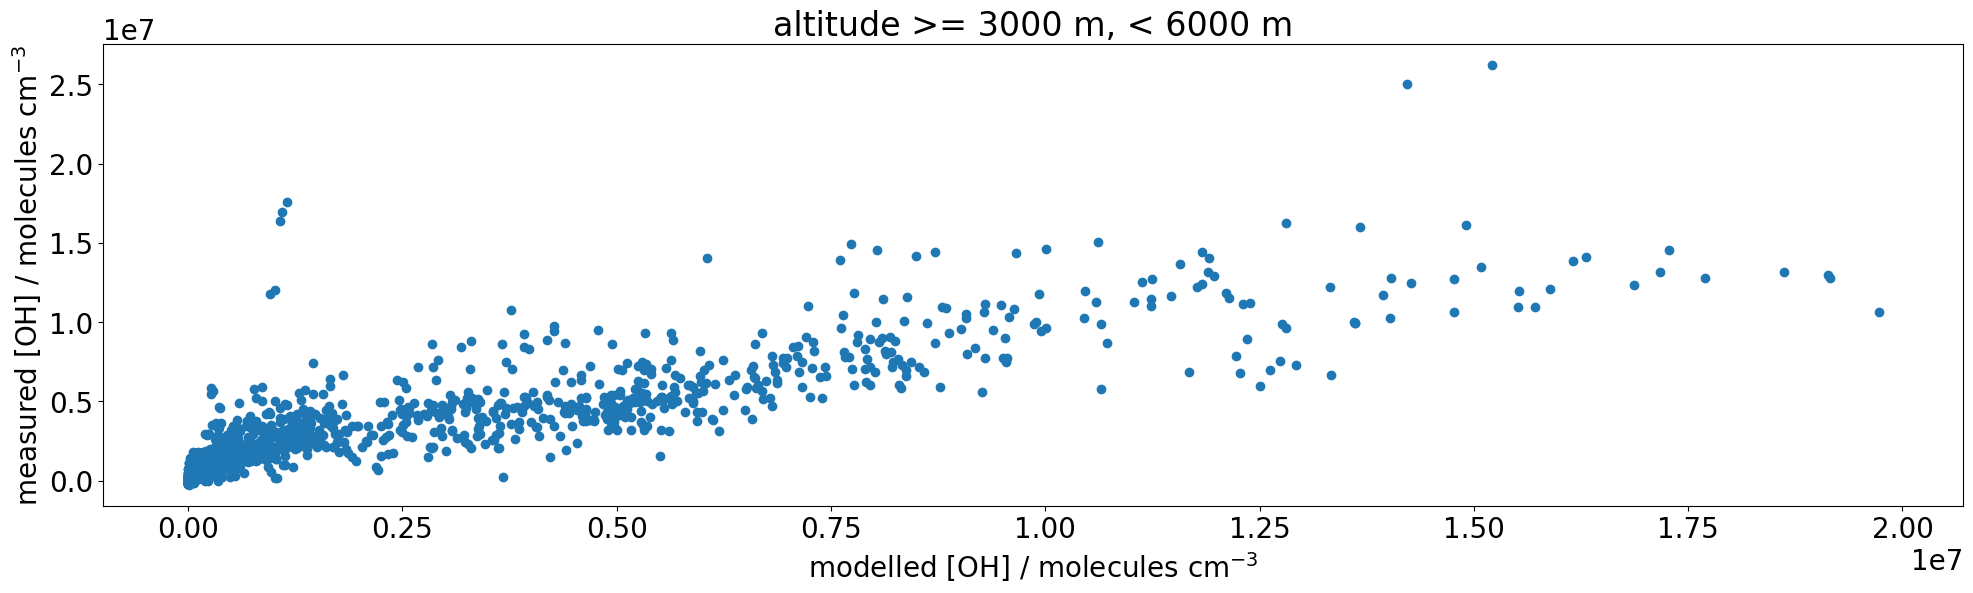

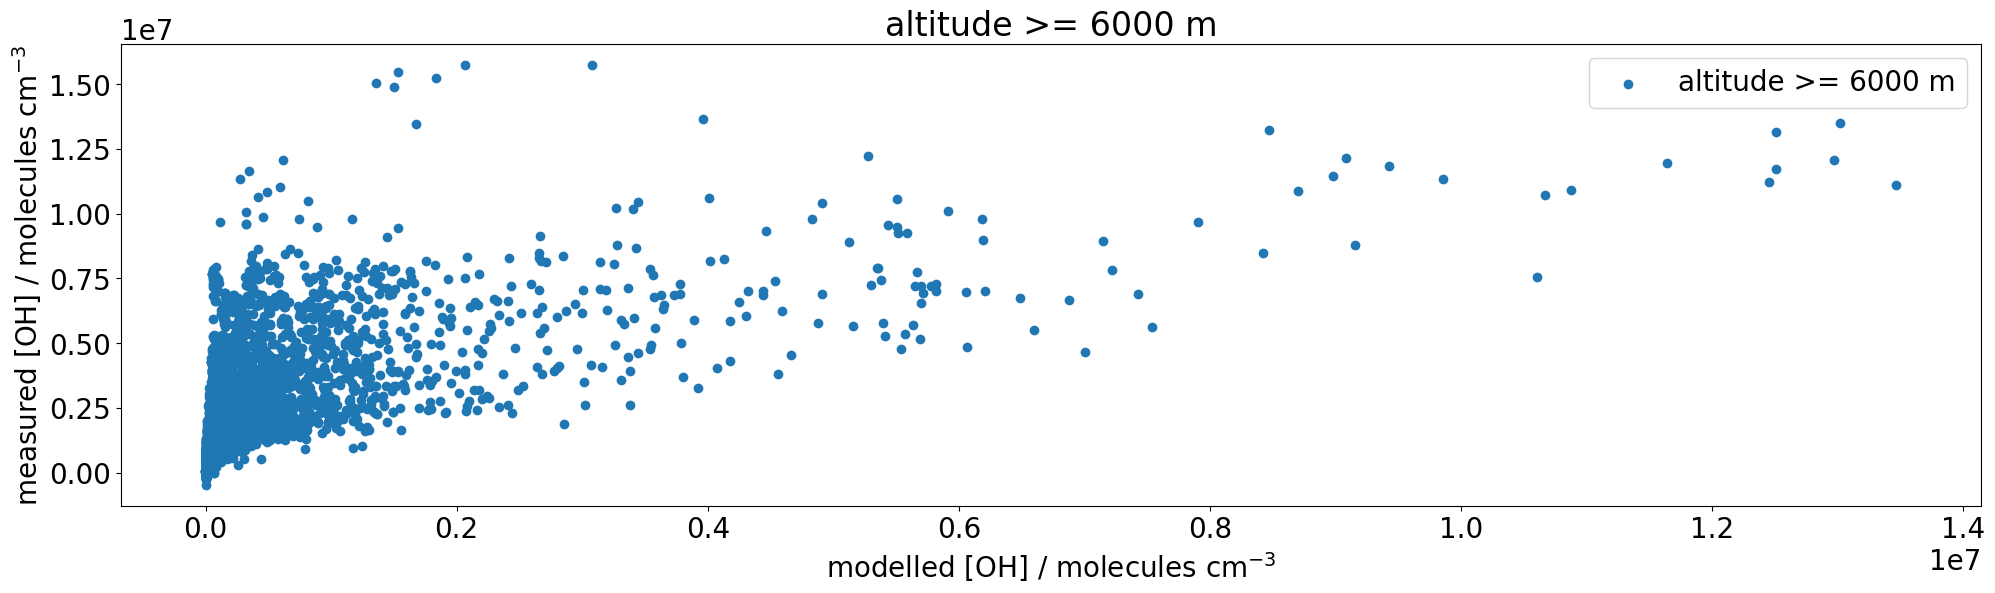

In [25]:
fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(df["[OH]_calc"][ (df["Altitude"] < 3000)], y = df["[OH]_measured"][(df["Altitude"] < 3000)], label = "altitude < 3000 m")
plt.title("altitude < 3000 m")
plt.xlabel("modelled [OH] / molecules cm$^{-3}$")
plt.ylabel("measured [OH] / molecules cm$^{-3}$")
fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(df["[OH]_calc"][(df["Altitude"] >= 3000) & (df["Altitude"] < 6000)], y = df["[OH]_measured"][(df["Altitude"] >= 3000) & (df["Altitude"] < 6000)], label = "altitude >= 3000 m, < 6000 m")
plt.title("altitude >= 3000 m, < 6000 m")
plt.xlabel("modelled [OH] / molecules cm$^{-3}$")
plt.ylabel("measured [OH] / molecules cm$^{-3}$")
fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(df["[OH]_calc"][(df["Altitude"] >= 6000)], y = df["[OH]_measured"][(df["Altitude"] >= 6000)], label = "altitude >= 6000 m")
plt.xlabel("modelled [OH] / molecules cm$^{-3}$")
plt.ylabel("measured [OH] / molecules cm$^{-3}$")
plt.title("altitude >= 6000 m")
plt.xlabel("modelled [OH] / molecules cm$^{-3}$")
plt.ylabel("measured [OH] / molecules cm$^{-3}$")
# ax.axline([0,0], [100,100])
plt.legend()

Can see a relatively positive correlation between modelled and measured values

In [26]:
df

,Temp,Pres,UTC_Start_dt,lat,lon,Altitude,jO3_O2_O1D_CAFS,O3_M,H2O_M,OH_ATHOS,...,[OH]_measured,O1D,source,kCO,kCH4,CO,CH4,[OH]_calc,sink,dOH/dt
0,249.265,343.334,2016-07-29 10:56:10-04:00,33.01171,241.10200,8804.58,0.000009,8.640570e-08,0.000447,0.300,...,2.994316e+06,0.023588,4.362068e+04,2.401161e-13,1.979626e-15,7.220262e+11,1.849609e+13,2.077319e+05,4.362068e+04,0.000000e+00
1,248.771,337.478,2016-07-29 10:56:40-04:00,32.96985,241.04760,8931.10,0.000009,7.601130e-08,0.000332,0.300,...,2.949089e+06,0.021093,2.855602e+04,2.402405e-13,1.951830e-15,6.783544e+11,1.819925e+13,1.438663e+05,2.855602e+04,-3.637979e-12
2,248.851,331.741,2016-07-29 10:57:10-04:00,32.92798,240.99323,9057.14,0.000009,8.291030e-08,0.000158,0.300,...,2.898024e+06,0.023270,1.475520e+04,2.402203e-13,1.956312e-15,6.867118e+11,1.788412e+13,7.379482e+04,1.475520e+04,0.000000e+00
3,246.160,315.391,2016-07-29 10:58:40-04:00,32.80281,240.83030,9425.14,0.000010,8.132570e-08,0.000169,0.276,...,2.562488e+06,0.023840,1.557405e+04,2.409072e-13,1.809564e-15,6.317127e+11,1.718857e+13,8.497041e+04,1.557405e+04,-1.818989e-12
4,245.201,309.998,2016-07-29 10:59:10-04:00,32.76114,240.77659,9550.39,0.000010,8.148520e-08,0.000207,0.276,...,2.528521e+06,0.024238,1.913352e+04,2.411561e-13,1.759244e-15,6.182354e+11,1.696073e+13,1.069334e+05,1.913352e+04,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6545,287.376,734.283,2016-08-23 15:51:00-04:00,34.94797,242.36580,2818.77,0.000048,5.419620e-08,0.007266,0.227,...,4.203003e+06,0.078281,4.230655e+06,2.319543e-13,5.089941e-15,2.751005e+12,3.497195e+13,5.183911e+06,4.230655e+06,0.000000e+00
6546,288.683,749.875,2016-08-23 15:51:30-04:00,34.91515,242.35962,2641.88,0.000047,5.082710e-08,0.007460,0.227,...,4.272818e+06,0.072279,4.073197e+06,2.317169e-13,5.234286e-15,2.485033e+12,3.549489e+13,5.348110e+06,4.073197e+06,-9.313226e-10
6547,290.545,771.085,2016-08-23 15:52:00-04:00,34.88332,242.34174,2403.69,0.000046,5.125980e-08,0.007838,0.240,...,4.615524e+06,0.071118,4.296305e+06,2.313828e-13,5.444657e-15,2.548761e+12,3.629920e+13,5.456484e+06,4.296305e+06,0.000000e+00
6548,291.259,777.013,2016-08-23 15:52:30-04:00,34.85163,242.32323,2339.75,0.000046,5.167830e-08,0.007777,0.240,...,4.639606e+06,0.071725,4.319411e+06,2.312559e-13,5.526811e-15,2.620191e+12,3.649122e+13,5.348356e+06,4.319411e+06,-9.313226e-10


In [27]:
from sklearn.metrics import r2_score

In [28]:
r2_score(df["[OH]_measured"], df["[OH]_calc"])

0.0500446321955883

In [29]:
df["ratio"] = (df["[OH]_calc"]/df["[OH]_measured"])
# df["ratio"].mean(axis=1)
df.mean()

/opt/jaspy/lib/python3.12/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Temp                                        251.486094
Pres                                        478.504676
UTC_Start_dt       2016-08-11 23:56:14.117557504-04:00
lat                                          18.829795
lon                                         255.985509
Altitude                                   6797.286937
jO3_O2_O1D_CAFS                               0.000031
O3_M                                               0.0
H2O_M                                         0.003564
OH_ATHOS                                      0.255629
CO_M                                               0.0
CH4_M                                         0.000002
PAN_M                                              0.0
date               2016-08-11 23:56:14.117557504-04:00
t                                       1170004.117557
M                               13299828468907390976.0
kH2O                                               0.0
kM                                                 0.0
O3        

## Machine learning experimentation

### Resampling - may be useful when doing less random train-test-splitting

In [30]:
df_resampled = df.resample('H', on = 'date').mean()
df_resampled

/tmp/ipykernel_19587/4156584304.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df.resample('H', on = 'date').mean()


,Temp,Pres,UTC_Start_dt,lat,lon,Altitude,jO3_O2_O1D_CAFS,O3_M,H2O_M,OH_ATHOS,...,O1D,source,kCO,kCH4,CO,CH4,[OH]_calc,sink,dOH/dt,ratio
date,,,,,,,,,,,,,,,,,,,,,
2016-07-29 10:00:00-04:00,247.112500,324.010333,2016-07-29 10:57:55-04:00,32.865557,240.912082,9235.043333,0.000010,8.160230e-08,0.000252,0.294167,...,0.023397,2.334426e+04,2.406665e-13,1.862659e-15,6.582537e+11,1.758839e+13,1.202611e+05,2.334426e+04,-1.515825e-12,0.042630
2016-07-29 11:00:00-04:00,258.114968,452.367921,2016-07-29 11:35:03.968253952-04:00,28.659382,239.589394,7403.947302,0.000016,7.030855e-08,0.004336,0.398476,...,0.031769,6.466035e+05,2.384413e-13,2.840948e-15,9.378670e+11,2.262957e+13,1.526769e+06,6.466035e+05,-1.761244e-12,0.338623
2016-07-29 12:00:00-04:00,260.225949,460.170810,2016-07-29 12:33:38.987341824-04:00,22.131498,239.483050,7103.483165,0.000033,6.708740e-08,0.004354,0.582177,...,0.066782,1.069782e+06,2.378298e-13,2.904211e-15,9.391355e+11,2.306539e+13,2.853488e+06,1.069782e+06,1.842015e-13,0.442593
2016-07-29 13:00:00-04:00,263.798296,524.906513,2016-07-29 13:29:00.260869632-04:00,15.938002,239.482985,6302.692870,0.000044,4.880488e-08,0.006954,0.525896,...,0.068506,1.132163e+06,2.371767e-13,3.279926e-15,9.998189e+11,2.564911e+13,2.833632e+06,1.132163e+06,6.263650e-12,0.453063
2016-07-29 14:00:00-04:00,269.373173,578.087933,2016-07-29 14:29:06.666666752-04:00,9.312558,239.481832,5379.119600,0.000059,2.934131e-08,0.010182,0.468867,...,0.055869,2.113861e+06,2.359021e-13,3.681951e-15,1.036939e+12,2.776743e+13,5.316204e+06,2.113861e+06,-5.684948e-11,0.727261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-08-23 11:00:00-04:00,264.409060,553.816738,2016-08-23 11:33:35.595238144-04:00,42.514223,265.800441,5686.553452,0.000033,5.417220e-08,0.006451,0.560321,...,0.051685,2.371368e+06,2.371175e-13,3.356802e-15,1.392960e+12,2.791286e+13,3.707730e+06,2.371368e+06,-6.409772e-12,0.483450
2016-08-23 12:00:00-04:00,270.359796,604.242713,2016-08-23 12:29:59.166666496-04:00,38.242088,263.583066,4987.736852,0.000042,4.399433e-08,0.010776,0.436454,...,0.060259,2.451660e+06,2.357298e-13,3.807022e-15,1.319843e+12,2.966159e+13,5.095872e+06,2.451660e+06,-4.085989e-11,0.718381
2016-08-23 13:00:00-04:00,239.147859,323.883131,2016-08-23 13:28:42.727272704-04:00,36.712338,258.620682,9752.801313,0.000052,6.732673e-08,0.002174,0.437061,...,0.099754,1.018285e+06,2.433477e-13,1.729412e-15,6.491542e+11,1.761014e+13,2.436183e+06,1.018285e+06,2.094594e-12,0.268327


In [31]:
(df_resampled.index)

DatetimeIndex(['2016-07-29 10:00:00-04:00', '2016-07-29 11:00:00-04:00',
               '2016-07-29 12:00:00-04:00', '2016-07-29 13:00:00-04:00',
               '2016-07-29 14:00:00-04:00', '2016-07-29 15:00:00-04:00',
               '2016-07-29 16:00:00-04:00', '2016-07-29 17:00:00-04:00',
               '2016-07-29 18:00:00-04:00', '2016-07-29 19:00:00-04:00',
               ...
               '2016-08-23 06:00:00-04:00', '2016-08-23 07:00:00-04:00',
               '2016-08-23 08:00:00-04:00', '2016-08-23 09:00:00-04:00',
               '2016-08-23 10:00:00-04:00', '2016-08-23 11:00:00-04:00',
               '2016-08-23 12:00:00-04:00', '2016-08-23 13:00:00-04:00',
               '2016-08-23 14:00:00-04:00', '2016-08-23 15:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='date', length=606, freq='h')

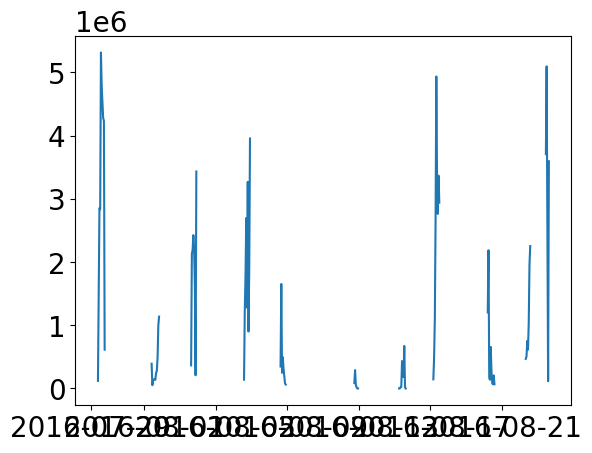

In [32]:
plt.plot(df_resampled.index, df_resampled["[OH]_calc"])

In [33]:
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

In [34]:
df_inputs = df[['Temp', 'Pres', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'CO_M', 'CH4_M']]

In [35]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Example data
X = df_inputs   # 100 samples, 5 input features
y = df["[OH]_calc"]  # single output

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# GBRT model
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)


MSE: 146678590823.67203


In [36]:
from sklearn.linear_model import LinearRegression
X = df_inputs
y = df["[OH]_calc"]
reg = LinearRegression().fit(X, y)
out_calc = reg.predict(X)
reg.score(X, y)


0.5602077131607408

In [37]:
from sklearn.linear_model import LinearRegression
X = df_inputs
y = df["[OH]_measured"]
reg = LinearRegression().fit(X, y)
out_measured = reg.predict(X)
reg.score(X, y)

0.4822014309236309

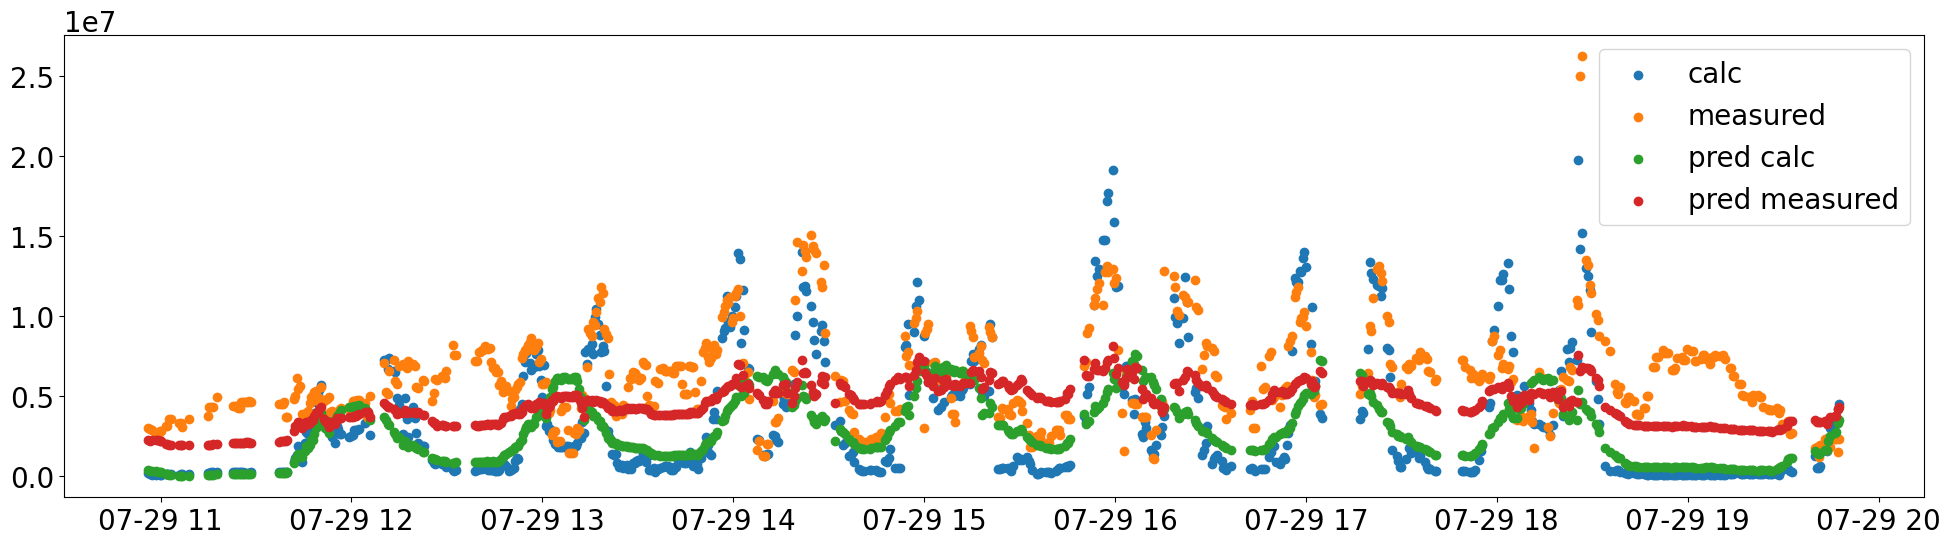

In [38]:
fig, ax = plt.subplots(figsize = (24, 6))
plt.scatter(df["date"][(df["date"] < "2016-07-30")], df["[OH]_calc"][(df["date"] < "2016-07-30")], label = "calc")
plt.scatter(df["date"][(df["date"] < "2016-07-30")], df["[OH]_measured"][(df["date"] < "2016-07-30")], label = "measured")
plt.scatter(df["date"][(df["date"] < "2016-07-30")], out_calc[(df["date"] < "2016-07-30")], label = "pred calc")
plt.scatter(df["date"][(df["date"] < "2016-07-30")], out_measured[(df["date"] < "2016-07-30")], label = "pred measured")
plt.legend()

In [39]:
df_inputs.shape

(6550, 7)

In [40]:
df_inputs.columns

Index(['Temp', 'Pres', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'CO_M', 'CH4_M'], dtype='object')

Feature: 0, Score: 44515.01601
Feature: 1, Score: -2310.17849
Feature: 2, Score: 38047545398.28625
Feature: 3, Score: 3590321228040.73828
Feature: 4, Score: 193940011.81066
Feature: 5, Score: -4917674906512.23242
Feature: 6, Score: 5515165786961.12793


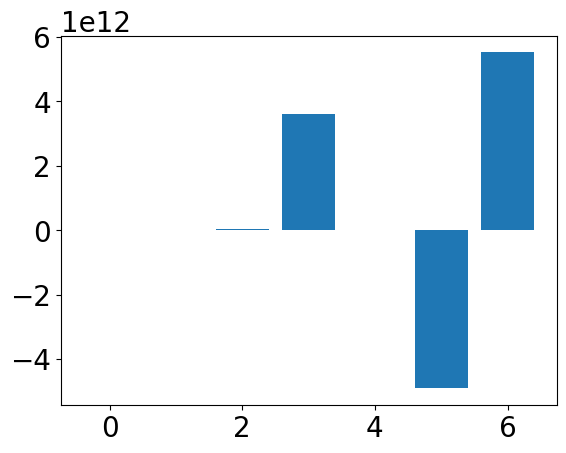

In [41]:
from sklearn.ensemble import RandomForestClassifier

X = df_inputs # 100 samples, 5 input features
y = df["[OH]_calc"]  # single output

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

model = LinearRegression()

model.fit(X_train, y_train)

importance = model.coef_

for i, v in enumerate(importance):
    print("Feature: %0d, Score: %.5f" % (i, v))

plt.bar([x for x in range(len(importance))], importance)
plt.show()    

In [42]:
df_inputs.columns

Index(['Temp', 'Pres', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'CO_M', 'CH4_M'], dtype='object')

In [43]:
from sklearn.ensemble import RandomForestRegressor


X = df_inputs   # 100 samples, 5 input features
y = df["[OH]_calc"]  # single output

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

model = RandomForestRegressor()


model.fit(X_train, y_train)

print(f"model score on training data: {model.score(X_train, y_train)}")
print(f"model score on testing data: {model.score(X_test, y_test)}")

model score on training data: 0.9967671122203501
model score on testing data: 0.9790392720493949


In [44]:
importances = model.feature_importances_

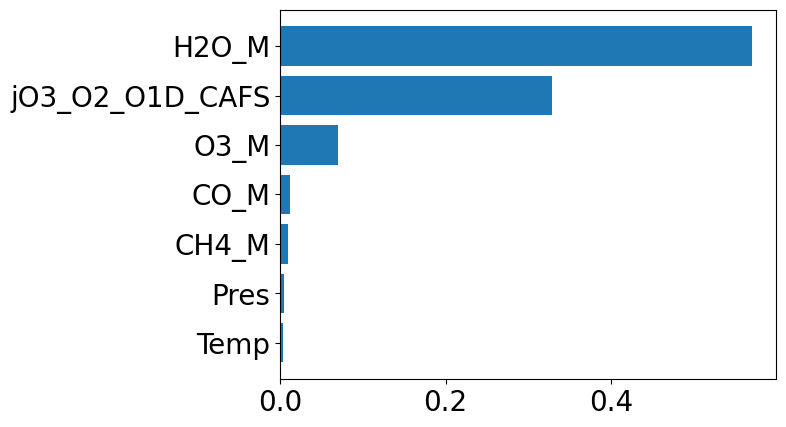

In [45]:
indices = np.argsort(importances)

fig, ax = plt.subplots()
ax.barh(range(len(importances)), importances[indices])
ax.set_yticks(range(len(importances)))
_ = ax.set_yticklabels(np.array(X_train.columns)[indices])

In [46]:
import sklearn
from sklearn.linear_model import Ridge

X = df_inputs   # 100 samples, 5 input features
y = df["[OH]_calc"]  # single output

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=1
)

ridgeReg = Ridge(alpha = 1)
ridgeReg.fit(X_train, y_train)

print(ridgeReg.score(X_train, y_train))
print(ridgeReg.score(X_test, y_test))

X = df_inputs   # 100 samples, 5 input features
y = df["[OH]_measured"]  # single output

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=1
)

ridgeReg = Ridge(alpha = 1)
ridgeReg.fit(X_train, y_train)

print(ridgeReg.score(X_train, y_train))
print(ridgeReg.score(X_test, y_test))

0.38512318997409944
0.3943896171416429
0.2585823245106136
0.258348466401525
